In [ ]:
#@@
# this file was fetched from ~/work/GETM/script_ms2/wave_analysis/wave_data_crm-long_rec_v2.ipynb
# focus on 1 tag: No. 225662

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
# import nc_time_axis
import matplotlib.pyplot as plt
import glob
import cmocean
import xskillscore as xs
import datetime
# from sklearn.metrics import mean_squared_error

import h5py
from scipy.io import loadmat
from scipy import signal
from scipy.interpolate import griddata
import cartopy.crs as ccrs

from scipy.signal import butter, filtfilt
from scipy import signal

In [2]:
## Working directory
wrk_dir = '~/work/OBS/dashcams_data/peru_data_acc/'

# 0. Functions

In [3]:
## filter

def power_spectral_density(accz_values, accz_rolling_5s):
    from scipy.signal import welch
    f_accz, Pxx_accz = welch(accz_values, fs=5, nperseg=200)
    f_accz_rolling, Pxx_accz_rolling = welch(accz_rolling_5s, fs=5, nperseg=200)
    return f_accz, Pxx_accz, f_accz_rolling, Pxx_accz_rolling

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def power_spectral_density_fft(accz_values):
    # from scipy.fft import fft
    # N = len(accz_values)
    # T = 1.0 / 5.0
    # yf = fft(accz_values)
    # yf_rolling = fft(accz_rolling_5s)
    # xf = np.fft.fftfreq(N, T)[:N//2]
    # return xf, 2.0/N * np.abs(yf[0:N//2]), 2.0/N * np.abs(yf_rolling[0:N//2])

    fs = 5.0
    N = len(accz_values)
    fft = np.fft.fft(accz_values)
    frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]  # Positive frequencies only
    psd = (1/(fs * N)) * np.abs(fft[:N//2])**2  # PSD
    psd[1:-1] *= 2  # Double non-DC/nyquist components for one-sided spectrum

    return frequencies, psd
def rotation_3d(accx_1, accy_1, accz_1):
    # Calculate mean acceleration vector - this represents the "true vertical"
        mean_accx = np.mean(accx_1)
        mean_accy = np.mean(accy_1)
        mean_accz = np.mean(accz_1)
        print(f"Mean acceleration: x = {mean_accx:.4f}, y = {mean_accy:.4f}, z = {mean_accz:.4f}")
        
        # Create unit vector for the true vertical direction
        mean_vec = np.array([mean_accx, mean_accy, mean_accz])
        mean_vec_norm = np.linalg.norm(mean_vec)
        print(f"Mean vector: {mean_vec}, norm: {mean_vec_norm}")
        if mean_vec_norm > 0:
            true_vertical = mean_vec / mean_vec_norm
        else:
            true_vertical = np.array([0, 0, 1])  # Default if norm is zero
            
        # Define the desired vertical direction (typically [0, 0, 1])
        desired_vertical = np.array([0, 0, 1])
        
        # Calculate the rotation axis and angle using cross product and dot product
        rotation_axis = np.cross(true_vertical, desired_vertical)
        rotation_axis_norm = np.linalg.norm(rotation_axis)
        print(f"Rotation axis: {rotation_axis}, norm: {rotation_axis_norm}")
        
        if rotation_axis_norm > 1e-10:  # Avoid division by zero
            rotation_axis = rotation_axis / rotation_axis_norm
            cos_angle = np.dot(true_vertical, desired_vertical)
            # Clamp to [-1, 1] to handle floating point errors
            cos_angle = max(min(cos_angle, 1.0), -1.0)
            rotation_angle = np.arccos(cos_angle)
            
            # Create rotation matrix using Rodrigues' rotation formula
            K = np.array([
            [0, -rotation_axis[2], rotation_axis[1]],
            [rotation_axis[2], 0, -rotation_axis[0]],
            [-rotation_axis[1], rotation_axis[0], 0]
            ])
            
            rotation_matrix = np.eye(3) + np.sin(rotation_angle) * K + (1 - np.cos(rotation_angle)) * np.dot(K, K)
            
            # Apply rotation to the acceleration vectors
            acc_vectors = np.column_stack((accx_1, accy_1, accz_1))
            rotated_acc = np.dot(acc_vectors, rotation_matrix.T)
            
            # Extract rotated components
            accx_rotated = rotated_acc[:, 0]
            accy_rotated = rotated_acc[:, 1]
            accz_rotated = rotated_acc[:, 2]
            
            print(f"Rotation angle: {rotation_angle * 180/np.pi:.2f} degrees")
            print(f"Mean before rotation: x = {mean_accx:.4f}, y = {mean_accy:.4f}, z = {mean_accz:.4f}")
            print(f"Mean after rotation: x = {np.mean(accx_rotated):.4f}, y = {np.mean(accy_rotated):.4f}, z = {np.mean(accz_rotated):.4f}")
        else:
            # Vectors are already aligned (or anti-aligned)
            accx_rotated = accx_1
            accy_rotated = accy_1
            accz_rotated = accz_1
            print("No rotation needed - vectors are already aligned")
        return accx_rotated, accy_rotated, accz_rotated


In [66]:
def rotation_3d_moving(accx_1, accy_1, accz_1):
    # Calculate mean acceleration vector - this represents the "true vertical"
    mean_accx = np.mean(accx_1)
    mean_accy = np.mean(accy_1)
    mean_accz = np.mean(accz_1)
    
    # Create unit vector for the true vertical direction
    mean_vec = np.array([mean_accx, mean_accy, mean_accz])
    mean_vec_norm = np.linalg.norm(mean_vec)
    if mean_vec_norm > 0:
        true_vertical = mean_vec / mean_vec_norm
    else:
        true_vertical = np.array([0, 0, 1])  # Default if norm is zero
        
    # Define the desired vertical direction (typically [0, 0, 1])
    desired_vertical = np.array([0, 0, 1])
    
    # Calculate the rotation axis and angle using cross product and dot product
    rotation_axis = np.cross(true_vertical, desired_vertical)
    rotation_axis_norm = np.linalg.norm(rotation_axis)
    
    if rotation_axis_norm > 1e-10:  # Avoid division by zero
        rotation_axis = rotation_axis / rotation_axis_norm
        cos_angle = np.dot(true_vertical, desired_vertical)
        # Clamp to [-1, 1] to handle floating point errors
        cos_angle = max(min(cos_angle, 1.0), -1.0)
        rotation_angle = np.arccos(cos_angle)
        
        # Create rotation matrix using Rodrigues' rotation formula
        K = np.array([
            [0, -rotation_axis[2], rotation_axis[1]],
            [rotation_axis[2], 0, -rotation_axis[0]],
            [-rotation_axis[1], rotation_axis[0], 0]
        ])
        
        rotation_matrix = np.eye(3) + np.sin(rotation_angle) * K + (1 - np.cos(rotation_angle)) * np.dot(K, K)
        
        # Apply rotation to the acceleration vectors
        acc_vectors = np.column_stack((accx_1, accy_1, accz_1))
        rotated_acc = np.dot(acc_vectors, rotation_matrix.T)
        
        # Extract rotated components
        accx_rotated = rotated_acc[:, 0]
        accy_rotated = rotated_acc[:, 1]
        accz_rotated = rotated_acc[:, 2]
        
        return accx_rotated, accy_rotated, accz_rotated, rotation_angle * 180/np.pi
    else:
        # Vectors are already aligned (or anti-aligned)
        return accx_1, accy_1, accz_1, 0

def moving_window_rotation(accx, accy, accz, window_size=100, step_size=50):
    """Apply rotation in moving windows and smoothly blend the results"""
    n = len(accx)
    
    # Initialize output arrays
    accx_rotated = np.zeros_like(accx)
    accy_rotated = np.zeros_like(accy)
    accz_rotated = np.zeros_like(accz)
    rotation_angles = np.zeros(n)
    
    # For each window, compute the rotation and apply it
    window_centers = np.arange(window_size//2, n-window_size//2, step_size)
    # print(window_centers,n)
    for center in window_centers:
        start = max(0, center - window_size//2)
        end = min(n, center + window_size//2)
        
        # Apply rotation to this window
        window_accx = accx[start:end]
        window_accy = accy[start:end]
        window_accz = accz[start:end]
        
        x_rot, y_rot, z_rot, angle = rotation_3d_moving(window_accx, window_accy, window_accz)
        
        # Store rotation angle for this window
        # rotation_angles[start:end] = angle
        rotation_angles[center] = angle
        
        # Store rotated values
        # accx_rotated[start:end] = x_rot
        # accy_rotated[start:end] = y_rot
        # accz_rotated[start:end] = z_rot
        accx_rotated[center] = x_rot[window_size//2]
        accy_rotated[center] = y_rot[window_size//2]
        accz_rotated[center] = z_rot[window_size//2]
    # Handle any remaining points
    # if window_centers[-1] + window_size//2 < n:
    # for center in range(window_centers[-1] + window_size//2, n):
    #     start = max(0, center - window_size//2)
    #     end = min(n, center + window_size//2)   
    #     x_rot, y_rot, z_rot, angle = rotation_3d_moving(accx[start:end], accy[start:end], accz[start:end])
    #     # print(len(accx[start:]),start)
    #     accx_rotated[start:] = x_rot
    #     accy_rotated[start:] = y_rot
    #     accz_rotated[start:] = z_rot
    #     rotation_angles[start:] = angle

    
    return accx_rotated, accy_rotated, accz_rotated, rotation_angles

# Example usage:
def analyze_chunk_with_rotation(chunk_data, fs=5, plot=True):
    # Convert raw acceleration to m/s^2
    accx = chunk_data["accx"].values/1000*9.81
    accy = chunk_data["accy"].values/1000*9.81
    accz = chunk_data["accz"].values/1000*9.81
    times = np.arange(len(accx))/fs
    
    # Apply low-pass filter (0.5 Hz) to get smooth trends
    # accx_lp = butter_lowpass_filter(accx, 0.5, fs, order=4)
    # accy_lp = butter_lowpass_filter(accy, 0.5, fs, order=4)
    # accz_lp = butter_lowpass_filter(accz, 0.5, fs, order=4)
    
    # Apply moving window rotation
    window_size = 100  # 20 seconds at 5 Hz
    # step_size = 50  # 10 seconds at 5 Hz
    step_size = 1
    
    accx_rotated, accy_rotated, accz_rotated, rotation_angles = moving_window_rotation(
        accx, accy, accz, window_size, step_size
    )
    
    if plot:
        fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
        
        # Plot raw and rotated x acceleration
        # axs[0].plot(times, accx, label='Raw accx')
        axs[0].plot(times[window_size//2:-window_size//2], (accx_rotated-accx)[window_size//2:-window_size//2], label='Rotated accx')
        axs[0].set_ylabel('Acceleration (m/s²)')
        axs[0].legend()
        axs[0].set_title('X-axis Acceleration')
        
        # Plot raw and rotated y acceleration
        # axs[1].plot(times, accy, label='Raw accy')
        axs[1].plot(times[window_size//2:-window_size//2], (accy_rotated-accy)[window_size//2:-window_size//2], label='Rotated accy')
        axs[1].set_ylabel('Acceleration (m/s²)')
        axs[1].legend()
        axs[1].set_title('Y-axis Acceleration')
        
        # Plot raw and rotated z acceleration
        # axs[2].plot(times, accz, label='Raw accz')
        axs[2].plot(times[window_size//2:-window_size//2], (accz_rotated-accz)[window_size//2:-window_size//2], label='Rotated accz')
        axs[2].set_ylabel('Acceleration (m/s²)')
        axs[2].legend()
        axs[2].set_title('Z-axis Acceleration')
        
        # Plot rotation angles
        axs[3].plot(times[window_size//2:-window_size//2], rotation_angles[window_size//2:-window_size//2])
        axs[3].set_ylabel('Rotation Angle (degrees)')
        axs[3].set_xlabel('Time (s)')
        axs[3].set_title('Rotation Angle Applied')
        
        plt.tight_layout()
        plt.show()
    
    return accx_rotated, accy_rotated, accz_rotated, rotation_angles

In [25]:

def get_depths_at_locations(lon_points, lat_points, bath_ds):
    """
    Get interpolated depth values at specified lon/lat points from a bathymetry dataset
    
    Parameters:
    -----------
    lon_points : array-like
        Longitude coordinates of points where depth is needed
    lat_points : array-like
        Latitude coordinates of points where depth is needed
    bath_ds : xarray.Dataset
        Bathymetry dataset with 'lon', 'lat', and 'elevation' variables
    
    Returns:
    --------
    depths : numpy.ndarray
        Interpolated depth values at the specified points
    """
    
    # Get the bathymetry grid coordinates and values
    lon_grid = bath_ds.lon.values
    lat_grid = bath_ds.lat.values
    depth_grid = bath_ds.elevation.values
    
    # Create 2D meshgrid from 1D coordinates
    lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)
    
    # Prepare points for interpolation
    points = np.column_stack((lon_2d.flatten(), lat_2d.flatten()))
    values = depth_grid.flatten()
    
    # Points to interpolate at
    xi = np.column_stack((lon_points, lat_points))
    
    # Perform interpolation
    depths = griddata(points, values, xi, method='linear')
    
    return depths

# # Get depths for all locations in Hs_df
# depths = get_depths_at_locations(Hs_df['lon'], Hs_df['lat'], bath1_region)

# # Add depths to the dataframe
# Hs_df['depth'] = depths

# # Print the updated dataframe
# print(f"Added depths to {len(Hs_df)} locations")

In [6]:
# Functions for wave eneregy concenvation 
# Wavenumber
def wavenumber(T, h, g):
    '''
    Inputs:
    T  -> wave period [s]
    h  -> water depth [m]
    g  -> gravitational acceleration [m/s^2]

    Output:
    k  -> wavenumber [rad/m]
    '''
    
    # kh - Deep water approximation
    kh_0 = 4 * (np.pi**2) * h / (g * (T**2))
    
    # kh - Explicit approximation (Beji, 2013)
    kh_B = kh_0 / np.sqrt(np.tanh(kh_0)) * (1 + kh_0**(1.09) * np.exp(-1.55 - 1.3 * kh_0 - 0.216 * (kh_0**2)))
    
    # kh - 1-step correction with Netwon's method (Simarro & Orfila, 2013)
    kh_next = (kh_B**2 + kh_0 * (np.cosh(kh_B)**2)) / (kh_B + np.sinh(kh_B) * np.cosh(kh_B))
    
    # k
    k = kh_next / h
    return k
# Wave celerity
def waveCel(k, T):
    '''
    Inputs:
    k  -> wavenumber [1/m]
    T  -> wave period [s]

    Output:
    C  -> wave celerity [m/s]
    '''
    C = 2*np.pi/(k*T)
    return C
# Wave group speed
def waveGroupSpeed(C, n):
    '''
    Inputs:
    C  -> wave celerity [m/s]
    n  -> wave group speed to wave speed ratio

    Output:
    Cg  -> wave group speed [m/s]
    '''
    Cg = C*n
    return Cg
# Wave group speed to wave speed ratio
def nRatio(k, h):
    '''
    Inputs:
    k  -> wavenumber [1/m]
    h  -> water depth [m]

    Output:
    n  -> wave group speed to wave speed ratio
    '''
    n = 0.5 * (1 + 2*k*h/np.sinh(2*k*h))
    return n

# Snell's Law
def Snell(theta_1, C_1, C_2):
    '''
    Inputs:
    theta_1 -> wave direction at depth 1 [deg] 
    C_1     -> wave celerity at depth 1 [m/s]
    C_2     -> wave celerity at depth 2 [m/s]

    Output:
    theta_2 -> wave direction at depth 2 [deg]
    '''
    theta_2 = np.arcsin(C_2*np.sin(np.deg2rad(theta_1))/C_1)
    theta_2 = np.degrees(theta_2)
    return theta_2


# 1. load raw data

## (1) read data from CSV (((can use NC file below directly)))

In [ ]:
file1=wrk_dir+'wave_acc/PERU_acc_raw_longrec_keepGPS_225662_v2_May20.csv'; ptime=165
# file1='surf_processed/Jul_Sep_2021.csv'; ptime=220
# file1='surf_processed/Oct_Dec_2021.csv'

# yr=file1[-21:-17]
# yr=file1[-13:-9]
df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')

In [ ]:
df[(pd.to_datetime(df['date'])>=pd.to_datetime('2025-4-24 3:36'))&(pd.to_datetime(df['date'])<=pd.to_datetime('2025-5-7 9:42'))]

In [ ]:
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')

In [ ]:
df['date2'] = df['t']
df = df.set_index('t')
df

In [ ]:
df2=df
# df1 = df.loc[df['device_id']==203013]

# x = xr.DataArray(df.Longitude_1, dims="t")
# y = xr.DataArray(df.Latitude_1, dims="t")
time = xr.DataArray(df2.date2, dims="t")
did = xr.DataArray(df2.device_id, dims="t")
accx = xr.DataArray(df2.acc_x,dims='t')
accy = xr.DataArray(df2.acc_y,dims='t')
accz = xr.DataArray(df2.acc_z,dims='t')
lon = xr.DataArray(df2.Longitude,dims='t')
lat = xr.DataArray(df2.Latitude,dims='t')
datatype = xr.DataArray(df2.datatype,dims='t')
# depth = xr.DataArray(df2.topography,dims='t')
# temp = xr.DataArray(df.ext_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs = xr.Dataset({
    # 'x': x,
    # 'y': y,
    # 'time': time,
    'id': did,
    'accx': accx,
    'accy': accy,
    'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    # 'depth': depth
    # 'temp': temp,
    # 'cond': conduc
})

In [ ]:
ds_obs.to_netcdf('PERU_acc_raw_v1_keep_gps_225662_May20.nc')

## (2) load NC files

In [7]:
ds_obs = xr.open_dataset(wrk_dir+'PERU_acc_raw_v1_keep_gps_225662_May20.nc',mode='r')
ds_obs

<xarray.Dataset>
Dimensions:   (t: 1426280)
Coordinates:
  * t         (t) datetime64[ns] 2022-10-05T19:16:57.278000 ... 2025-05-19T02...
Data variables:
    id        (t) int64 ...
    accx      (t) int64 ...
    accy      (t) int64 ...
    accz      (t) int64 ...
    lon       (t) float64 ...
    lat       (t) float64 ...
    datatype  (t) object ...

# 2. load Bathymetry data (GEBCO)

In [9]:
# coordinate of the box
x_geobox = [-80,-78.5]
y_geobox = [-9.2, -7]

In [10]:
# Load bathymetry data
wrk_dir_ms2 = '/home/server/pi/homes/liux8/work/GETM/scripts_ms2/waves_analysis/'
bath1 = xr.open_dataset(wrk_dir_ms2 + 'GEBCO_2021_sub_ice_topo.nc')

# Filter the bathymetry data to the region within [x_geobox, y_geobox]
bath1_region = bath1.sel(lon=slice(x_geobox[0], x_geobox[1]), lat=slice(y_geobox[0], y_geobox[1]))
bath1_region
lon_bath = bath1_region.lon.values
lat_bath = bath1_region.lat.values
depth_bath = bath1_region.elevation.values

# 3. find the locations of the tags in Peru Coast

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs.lon,ds_obs.lat,'o')

ax.coastlines()
ax.set_xlim(-82,-75)
ax.set_ylim(-12,-4)
ax.set_xticks(np.arange(-80,-75,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-12,-4,2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

## Define GEO box

In [11]:
ds_obs_peru_box = ds_obs.where((ds_obs.lon>x_geobox[0])&(ds_obs.lon<x_geobox[1])&(ds_obs.lat>y_geobox[0])&(ds_obs.lat<y_geobox[1]),drop=True)
ds_obs_peru_box

<xarray.Dataset>
Dimensions:   (t: 29874)
Coordinates:
  * t         (t) datetime64[ns] 2025-01-22T14:57:59 ... 2025-05-19T02:20:23
Data variables:
    id        (t) float64 2.257e+05 2.257e+05 2.257e+05 ... 2.257e+05 2.257e+05
    accx      (t) float64 -111.0 -62.0 -449.0 -347.0 ... 92.0 224.0 -302.0
    accy      (t) float64 319.0 -928.0 -881.0 -892.0 ... -992.0 -960.0 -875.0
    accz      (t) float64 1.053e+03 463.0 285.0 432.0 ... 367.0 341.0 372.0
    lon       (t) float64 -79.5 -79.5 -79.5 -79.5 ... -78.97 -78.97 -78.97
    lat       (t) float64 -7.814 -7.814 -7.814 -7.814 ... -8.566 -8.566 -8.566
    datatype  (t) object GPS GPS GPS GPS GPS GPS ... GPS GPS GPS GPS GPS GPSS

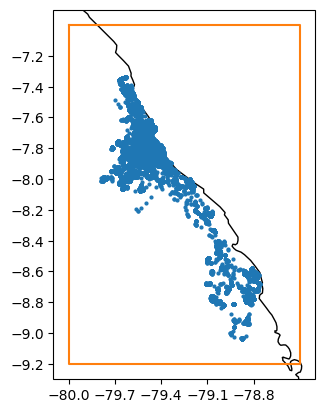

In [12]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs_peru_box.lon,ds_obs_peru_box.lat,'o',markersize=2)
plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

ax.coastlines()
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# plotting locations by device id

## 1. find tag IDs and their locations

In [13]:
print( 'tags in the box:' , np.unique(ds_obs_peru_box.id))

tags in the box: [225662.]


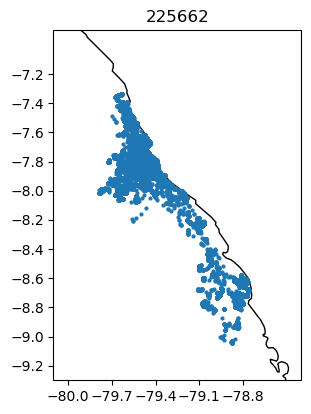

In [14]:
# ax = plt.axes(projection=ccrs.PlateCarree())
# plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

# ax.coastlines()
# ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
# ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
fig = plt.figure(figsize=(12,10))
kk=1
for idnn in np.unique(ds_obs.id):
    ax = fig.add_subplot(2,3,kk,projection=ccrs.PlateCarree())
    kk = kk+1
    # plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])
    
    ax.coastlines()
    ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
    ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
    ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
    plt.plot(ds_obs_peru_box.lon.where(ds_obs_peru_box.id==idnn),ds_obs_peru_box.lat,'o',markersize=2)
    plt.title(f'{idnn}')
    

## data in this region

In [ ]:
for id in np.unique(ds_obs_peru_box.id):

    ds_obs_peru_box_singetag = ds_obs_peru_box.where(ds_obs_peru_box.id==id,drop=True)
    print(f'ID= {id} GPS signals {ds_obs_peru_box_singetag.accx.size}')

# process all tags

In [15]:
# Create a new integer coordinate
new_t = np.arange(len(ds_obs['t']))

# Optionally, store the original time as a data variable for reference
ds_obs = ds_obs.assign(original_time=('time_index', ds_obs['t'].values))

# Assign the new integer coordinate while keeping the original as a variable
ds_obs = ds_obs.assign_coords(t=new_t).rename({'t': 'time_index'})

# assign a new variable 'mask' (with NaNs)
ds_obs = ds_obs.assign(mask=(('time_index',), np.full(ds_obs.dims['time_index'], np.nan)))

In [16]:
# add a new variable 'mask'. the values are 0,1,2,3,... for each gap (between GPS signals)
gps_indices_a = ds_obs.time_index.where(ds_obs.datatype == 'GPS', drop=True).values.astype(int)
# print(gps_indices[:400])

indices = [(i, j, j-i) for i, j in zip(gps_indices_a[:-1], gps_indices_a[1:]) if j - i > 10]
imask = 0
for idx in indices:
    # print(idx)
    ds_obs['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
    imask = imask+1

print(f'total gaps between GPS: {imask}')

total gaps between GPS: 1629


In [17]:
## find tag location inside the [x_geobox, y_geobox] 

######
lon_lat_indices_1 = ds_obs.isel(time_index=np.array(indices)[:,0])
lon_lat_indices_1 = lon_lat_indices_1.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_1["time_index"]))))

lon_lat_indices_2 = ds_obs.isel(time_index=np.array(indices)[:,1])
lon_lat_indices_2 = lon_lat_indices_2.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_2["time_index"]))))

lon_lat_indices_1_in_box = lon_lat_indices_1.where(
    (lon_lat_indices_1.lon > x_geobox[0]) & (lon_lat_indices_1.lon < x_geobox[1]) &
    (lon_lat_indices_1.lat > y_geobox[0]) & (lon_lat_indices_1.lat < y_geobox[1]),
    drop=True
)
lon_lat_indices_2_in_box = lon_lat_indices_2.where(
    (lon_lat_indices_2.lon > x_geobox[0]) & (lon_lat_indices_2.lon < x_geobox[1]) &
    (lon_lat_indices_2.lat > y_geobox[0]) & (lon_lat_indices_2.lat < y_geobox[1]),
    drop=True
)
# lon_lat_indices_1_in_box

common_indices = np.intersect1d(lon_lat_indices_1_in_box.index_local, lon_lat_indices_2_in_box.index_local)

# print(lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==common_indices[1],drop=True).time_index.values)
# print(lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==common_indices[1],drop=True).time_index.values)
######
print(f'number of GPS signals in the box: {len(common_indices)}')


number of GPS signals in the box: 1623


4 (9831, 10153) 225662 -79.49271392822266 -7.823023319244385 -79.40239715576173 -7.860538482666016
5 (10153, 10887) 225662 -79.40239715576173 -7.860538482666016 -79.41743469238281 -7.821780204772949
6 (10894, 11456) 225662 -79.4641876220703 -7.782068252563477 -79.40702056884764 -7.819501876831055
7 (11456, 11728) 225662 -79.40702056884764 -7.819501876831055 -79.49820709228516 -7.813836574554443
8 (11735, 11815) 225662 -79.49810791015625 -7.813953399658203 -79.46822357177734 -7.754876613616943
9 (11815, 12764) 225662 -79.46822357177734 -7.754876613616943 -79.43996429443358 -7.758218288421631
10 (12764, 13098) 225662 -79.43996429443358 -7.758218288421631 -79.49820709228516 -7.813950061798096
11 (13111, 14094) 225662 -79.49275970458984 -7.770748138427734 -79.48453521728516 -7.707076549530029
12 (14094, 14780) 225662 -79.48453521728516 -7.707076549530029 -79.48393249511719 -7.693841934204102
13 (14780, 15317) 225662 -79.48393249511719 -7.693841934204102 -79.46508789062499 -7.76339817047119

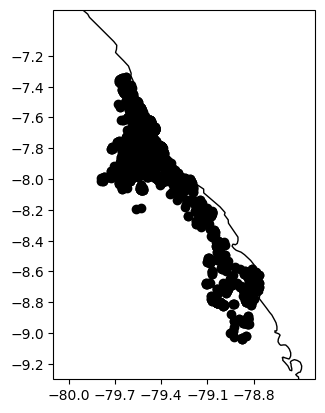

In [18]:
# add variable 'mask2' to ds_obs (sub chunks in a chunk between GPS signals)
# add variables 'x1', 'y1', 'x2', 'y2' to ds_obs (lon, lat of the GPS signals before and after the chunk)
# Define indices_inbox list
indices_inbox_a = []
ds_obs['mask2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
imask = 0

ax = plt.axes(projection=ccrs.PlateCarree())
# first find the indices whose GPS location is in the box
# for idx in indices:
for idx2 in common_indices:
#     print(idx2)
    idx = (lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==idx2,drop=True).time_index.values[0],
            lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==idx2,drop=True).time_index.values[0])
    # p1 = ds_obs.isel(time_index=idx[0])
    p1 = ds_obs.isel(time_index=idx[0])
    p2 = ds_obs.isel(time_index=idx[1])

    # if (x_geobox[0] < p1.lon.values < x_geobox[1]) & (y_geobox[0] < p1.lat.values < y_geobox[1]) & \
    #    (x_geobox[0] < p2.lon.values < x_geobox[1]) & (y_geobox[0] < p2.lat.values < y_geobox[1]):
    #         indices_inbox_a.append(idx)
            # Check if records between idx[0] and idx[1] have the datatype SEN_ALL_1Hz_START and SEN_ALL_1Hz_END
    if 'SEN_ACC_5Hz' in ds_obs.datatype.isel(time_index=slice(idx[0], idx[1])).values:
        ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))] = xr.where(
            ds_obs.datatype.isin(['SEN_ACC_5Hz', 'SEN_ACC_5Hz_START', 'SEN_ACC_5Hz_END']).loc[dict(time_index=slice(idx[0], idx[1]))],
            imask,
            ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))]
        )
        ds_obs['x1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lon.values
        ds_obs['y1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lat.values
        ds_obs['x2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lon.values
        ds_obs['y2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lat.values
        imask += 1
        print(idx2, idx,p1.id.values,p1.lon.values, p1.lat.values,p2.lon.values, p2.lat.values)
        plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'ok')

ax.coastlines()
# ax.set_xlim(-125,-123)
# ax.set_ylim(44,47)
# ax.set_xticks(np.arange(-124.7,-124,0.3), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(46,47,0.2), crs=ccrs.PlateCarree())
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# for idx in indices:
#     # print(dfs.loc[idx[0]:idx[1]])
#     dfs_chunk = dfs.loc[idx[0]:idx[1]]
#     sen_start = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_START')]
#     sen_end = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_END')]
#     print(sen_start,sen_end)

#     if not sen_start.empty and not sen_end.empty:
#         chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]
#         if 'chunk_acc' in locals():
#             chunk_acc = pd.concat([chunk_acc, dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]])
#         else:
#             chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]

#  sub-chunks divided by START and END signals

In [19]:
### total number of chunks (THIS "chunk" is coarsely divided by GPS signals) in the box for acc data
len(np.unique(ds_obs.mask2))

1622

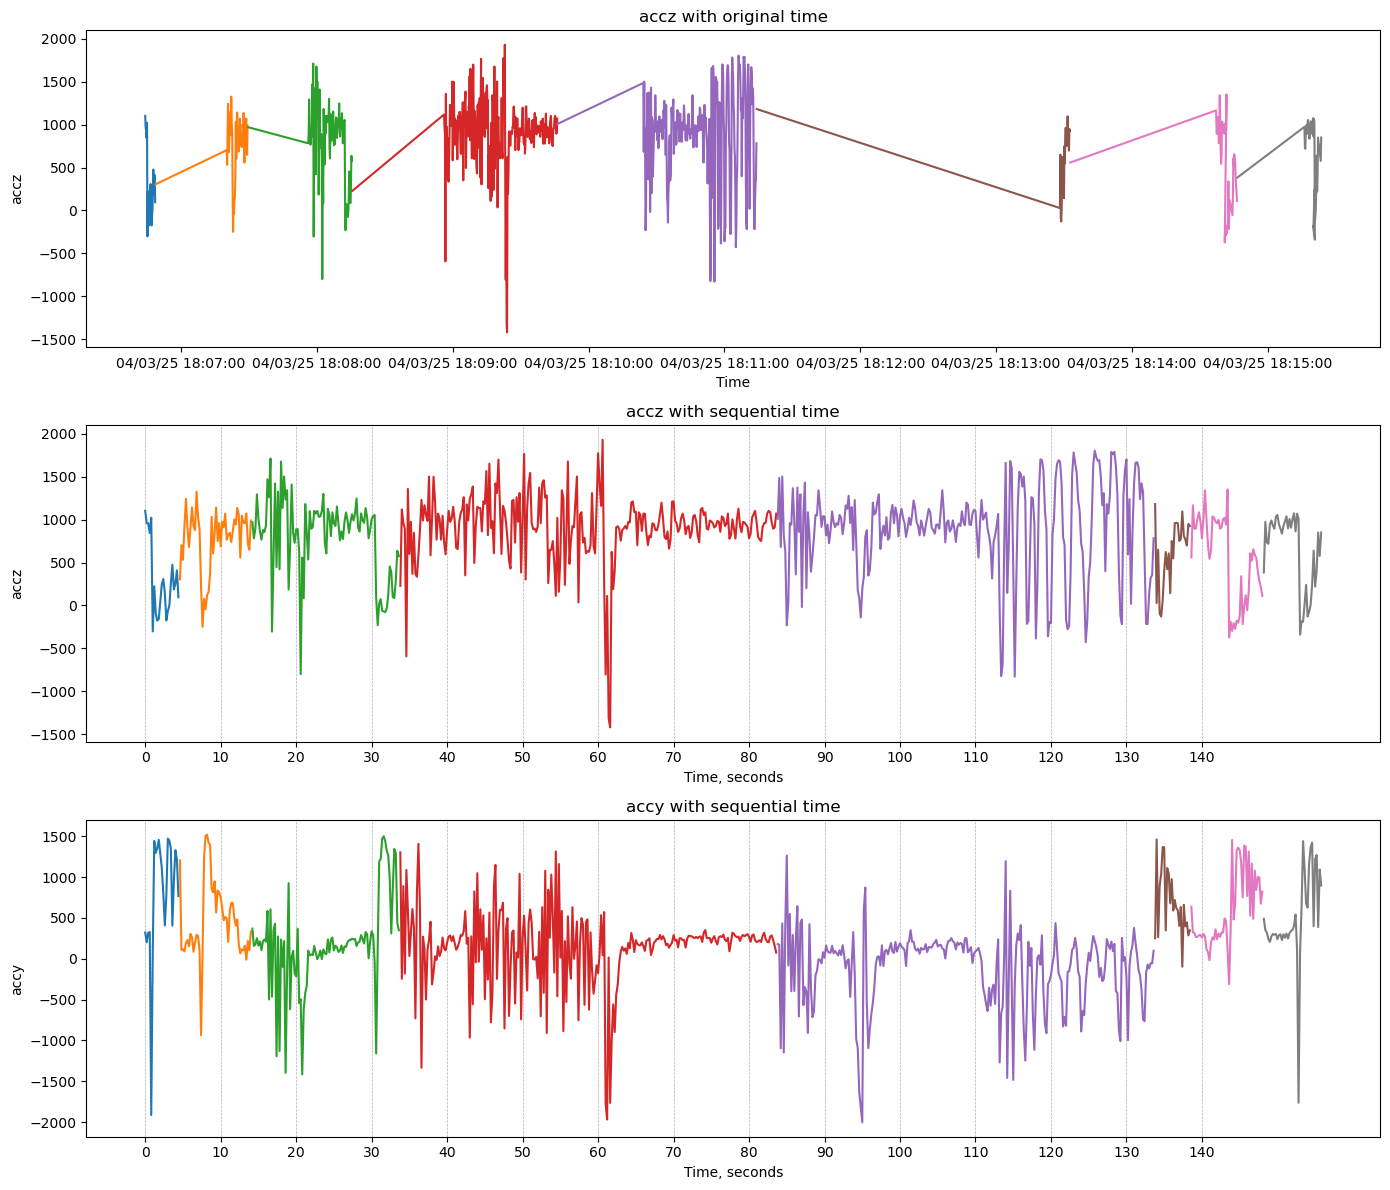

In [20]:
ik = 1000

data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik + 1, drop=True)

# Calculate the time difference between consecutive points
time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

# Find the indices where the time difference is greater than 2 seconds
cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

# Split the data_chunk_8 into pieces based on the cut_indices
data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices], np.r_[cut_indices, len(data_chunk_8.time_index)])]

fig, axs = plt.subplots(3, 1, figsize=(14, 12))

# Plot accz with original time
colors = plt.cm.viridis(np.linspace(0, 1, len(data_pieces)))
for i, piece in enumerate(data_pieces):
    axs[0].plot(piece['original_time'], piece['accz'])
axs[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%D %H:%M:%S'))
axs[0].set_xlabel('Time')
axs[0].set_ylabel('accz')
axs[0].set_title('accz with original time')

# Plot accz with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[1].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accz'])
    xstart = xstart + len(piece['original_time'])
axs[1].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[1].set_xticks(np.arange(0, 145, 10))
axs[1].set_xlabel('Time, seconds')
axs[1].set_ylabel('accz')
axs[1].set_title('accz with sequential time')

# Plot accy with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[2].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accy'])
    xstart = xstart + len(piece['original_time'])
axs[2].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[2].set_xticks(np.arange(0, 145, 10))
axs[2].set_xlabel('Time, seconds')
axs[2].set_ylabel('accy')
axs[2].set_title('accy with sequential time')

plt.tight_layout()
plt.show()


# get Chunks by searching continous ACC singals in the box
# calculate general parameters of each chunk (record length, x,y, ...)

In [21]:
# Split the data_chunk_8 into pieces based on the cut_indices
# store the data longer than 40s in a pandas dataframe

data_length = []
data_time_length = []
data_time_length_df = pd.DataFrame(columns=["data_time_length", "mask_ik"])
data_40s_df = pd.DataFrame(columns=["mask_ik","accz","bird_id","lon","lat","original_time","chunk_id"])

# for ik in [8,9,10]:
ichunk_nogap=0
ichunk_nogap_20250211=0
# for ik in range(188,189):
for ik in np.unique(ds_obs.mask2)[1:]:

    if ik % 100 == 0:
        print(ik)

    data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik, drop=True)

    # Calculate the time difference between consecutive points
    time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

    # Find the indices where the time difference is greater than 2 seconds
    cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

    # Split the data_chunk_8 into pieces based on the cut_indices
    data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices+1], np.r_[cut_indices+1, len(data_chunk_8.time_index)+1])]
    data_length = [len(piece['original_time']) for piece in data_pieces]
    data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    data_time = [piece['original_time'][0].values for piece in data_pieces]
    for i, piece in enumerate(data_pieces):
        # print(i,data_time_length[i])
        if data_time_length[i]>39:
            data_40s_df = pd.concat([data_40s_df, pd.DataFrame({"mask_ik": [ik]*(data_length[i]),
                                                                 "accz": piece['accz'].values,
                                                                 "accy": piece['accy'].values,
                                                                 "accx": piece['accx'].values,
                                                                 "bird_id": [data_chunk_8.id[0].values]*(data_length[i]),
                                                                 "lon":[piece['x1'][0].values]*(data_length[i]),
                                                                 "lat":[piece['y1'][0].values]*(data_length[i]),
                                                                 "original_time":piece['original_time'].values,
                                                                 "chunk_id":[ichunk_nogap]*(data_length[i])})], ignore_index=True)
        ichunk_nogap = ichunk_nogap+1
        if data_time[i]> pd.to_datetime('2025-2-11'):
            ichunk_nogap_20250211 = ichunk_nogap_20250211+1
    # print(len(data_time_length))
    # Store data_time_length in a xarray DataArray with mask_ik
    data_time_length_df = pd.concat([data_time_length_df, pd.DataFrame({"data_time_length": data_time_length,"original_time":data_time, "mask_ik": [ik] * len(data_time_length),"bird_id": [data_chunk_8.id[0].values]*len(data_time_length)})], ignore_index=True)

    # data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    # print(data_time_length)
    # data_length
    # data_time = [piece['original_time'] for piece in data_pieces]
    # for i, piece in enumerate(data_pieces):
    #     print(i, len(piece['original_time']), piece['original_time'][0], piece['original_time'][-1])


100.0
200.0
300.0
400.0
500.0
600.0
700.0
800.0
900.0
1000.0
1100.0
1200.0
1300.0
1400.0
1500.0
1600.0


In [ ]:
for i in data_40s_df["chunk_id"].unique():
    fig = plt.figure(figsize=(12,3),constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    axs1 = fig.add_subplot(gs[0])
    axs2 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accz'].values,label='accz')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accy'].values,label='accy')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accx'].values,label='accx')
    axs1.set_ylim(-1000,2000)
    axs1.set_title(f'chunk_id={i},STD={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)}, MEAN_accz={np.mean(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values):.3f}, STD_accy={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accy"].values):.3f}, STD_accx={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accx"].values):.3f}')
    axs1.text(0,1700, f'{data_40s_df[data_40s_df["chunk_id"]==i]["original_time"].values[0]}')
    axs1.legend(loc='upper right')

    # axs2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
    axs2.plot(data_40s_df[data_40s_df["chunk_id"]==i]['lon'].iloc[0], data_40s_df[data_40s_df["chunk_id"]==i]['lat'].iloc[0], 'o')
    axs2.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
    axs2.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
    axs2.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
    axs2.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
    # ax2.set_xticks(np.arange(-124.7, -124, 0.3), crs=ccrs.PlateCarree())
    # ax2.set_yticks(np.arange(46, 47, 0.2), crs=ccrs.PlateCarree())
    axs2.coastlines()
    axs2.set_title('Location')
    axs2.set_xlabel('Longitude')
    axs2.set_ylabel('Latitude')
    
    plt.savefig(f'chunk_40s_225662/chunk_{i}.png')
    plt.close()

## Count GOOD data / total 

In [ ]:
# get standard deviation of accz for each chunk
time_accz = pd.DataFrame(columns=["time_accz","std_accz"])
for i in data_40s_df["chunk_id"].unique():
    std_accz=np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)
    time_accz = pd.concat([time_accz, pd.DataFrame({"time_accz": [data_40s_df[data_40s_df["chunk_id"]==i]['original_time'].iloc[0]],
                                                    "std_accz":std_accz})], ignore_index=True)

In [ ]:
# Group time_accz by date and count number of records in each group with std_accz < 400 (good data)
time_accz['date'] = time_accz['time_accz'].dt.date
filtered_time_accz = time_accz[time_accz['std_accz'] < 400]
grouped_time_accz = filtered_time_accz.groupby('date').size()
grouped_time_accz_total = time_accz.groupby('date').size()
grouped_time_accz_df = grouped_time_accz.reset_index(name='good data')
# Add the total count to the dataframe
grouped_time_accz_df['total'] = grouped_time_accz_df['date'].map(grouped_time_accz_total)
# grouped_time_accz_df['total'] = grouped_time_accz_total.values
print(grouped_time_accz_df)
# print(grouped_time_accz)
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['total'], alpha=0.5, label='Total')
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['good data'], label='STD_accz < 400')
plt.xticks(rotation=45)
plt.legend()
# plt.show()

## plot all the chunks longer than 40s, adding a map for the locations

In [ ]:
# Filter the data for the specific date
# just for 2025-02-18
filtered_chunks = data_40s_df[data_40s_df['original_time'].dt.date == datetime.date(2025, 2, 18)]

# Get the unique chunk IDs for the filtered data
unique_chunks = filtered_chunks['chunk_id'].unique()

# Plot the chunks
for chunk_id in unique_chunks:
    chunk_data = filtered_chunks[filtered_chunks['chunk_id'] == chunk_id]
    if np.std(chunk_data['accz'])<400: # only plot the data with std < 400 (good data)
        # plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
    else: # save the chunks with std>400 (bad data)
        plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots_2/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
        # break

### for chunk > 100 s

In [ ]:
icount=0
for chunk_id in data_40s_df.chunk_id.unique():
    # print(ik)
    # Display the rows for the first chunk_id in the dataframe
    chunk_data = data_40s_df[data_40s_df["chunk_id"]==chunk_id]
    
    # Display basic info about the chunk
    if len(chunk_data) > 500:

        # plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on {chunk_data['original_time'].values[0]}, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots_100s_v3/chunk_2025-02-18_{chunk_id}.png')
        plt.close()

# print(icount)


## Pick up good data from 100s chunks

In [ ]:
# record list 
rec_list = [7941,8010, 8013, 8029, 8435, 8437, 8438, 8439, 8440, 8444, 8450, 8452, 8463, 8471, 8473, 8478, 8480, 8482, 8508, 8552, 8554, 8555, 8557, 8565, 8570, 8572,
 8582, 8588, 8589, 8604, 8605, 8614, 8622, 8637, 8638, 8639, 8641, 8653, 8654, 8655, 8660, 8671, 8677, 8713, 8738, 8778, 8787, 8892, 8995, 9006, 9020, 9032, 9037,
 9082, 9085, 9086, 9102, 9127, 9141, 9144, 9164, 9165, 9207, 9215, 9219, 9230, 9238, 9263, 9267, 9287, 9291, 9295, 9311, 9312, 9316, 9322, 9323, 9327, 9332, 9347,
 9363, 9378, 9401, 9405, 9416, 9417, 9424, 9428, 9451, 9456, 9508, 9512, 9551, 9565, 9625, 9646, 9676, 9685, 9689, 9690, 9755, 9758, 9759, 9767, 9768, 9808, 9834,
 9867, 9873, ]

# Create a directory for copied files if it doesn't exist

# Create output directory if it doesn't exist
output_dir = 'good_chunks_225662'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through each chunk_id in our list
for chunk_id in rec_list:
    # Find the chunk data
    source_file = f'chunk_plots_100s_v3/chunk_2025-02-18_{chunk_id}.png'
    target_file = f'{output_dir}/chunk_2025-02-18_{chunk_id}.png'
        
    # Copy the file if it exists
    if os.path.exists(source_file):
        shutil.copy(source_file, target_file)
        print(f"Copied chunk {chunk_id} to {target_file}")
    else:
        # If the file doesn't exist, print a message
        print(f"Error generating plot for chunk {chunk_id}")


In [22]:
rec_list2_better = [8557, 8570, 8589, 8605, 8639, 8654, 8655, 8677, 8787, 8892, 9102, 9127, 9164, 9215, 9295, 9323, 9347, 9405, 9417, 9424, 9428, 
             9451, 9512, 9565, 9625, ]

### (1) plot Original acceleration 

In [ ]:
# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_better:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    # accx_rotated,accy_rotated,accz_rotated = rotation_3d(accx_1, accy_1, accz_1)
    accz_rotated, accx_rotated, accy_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)
    # accz_1_filtered_1s = butter_lowpass_filter(accz_1, 1/2, sample_rate, order)
    # accx_1_filtered_1s = butter_lowpass_filter(accx_1, 1/2, sample_rate, order)
    # accy_1_filtered_1s = butter_lowpass_filter(accy_1, 1/2, sample_rate, order)      
    # f_accz, Pxx_accz, f_accz_butt_1s, Pxx_accz_butt_1s = power_spectral_density(accz_1, accz_1_filtered_1s)
    # f_accx, Pxx_accx, f_accx_butt_1s, Pxx_accx_butt_1s = power_spectral_density(accx_1, accx_1_filtered_1s)
    # f_accy, Pxx_accy, f_accy_butt_1s, Pxx_accy_butt_1s = power_spectral_density(accy_1, accy_1_filtered_1s)  
    accz_1_detrended = signal.detrend(accz_rotated)
    accx_1_detrended = signal.detrend(accx_rotated)
    accy_1_detrended = signal.detrend(accy_rotated)
    f_accz, Pxx_accz = power_spectral_density_fft(accz_1_detrended)
    f_accx, Pxx_accx = power_spectral_density_fft(accx_1_detrended)
    f_accy, Pxx_accy = power_spectral_density_fft(accy_1_detrended)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1))

    Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    # if icount == 0:
    #     PSD_acc = [Pxx_accz]
    #     f_accz_all = [f_accz]
    #     PSD_eta = [Pxx_eta]
    #     t_april = [chunk00['original_time'].iloc[0]]
    #     x_april = [chunk00['lon'].iloc[0]]
    #     y_april = [chunk00['lat'].iloc[0]]
    # else:
    #     PSD_acc.append(Pxx_accz)
    #     f_accz_all.append(f_accz)
    #     PSD_eta.append(Pxx_eta)
    #     t_april.append(chunk00['original_time'].iloc[0])
    #     x_april.append(chunk00['lon'].iloc[0])
    #     y_april.append(chunk00['lat'].iloc[0])
    # icount += 1

    fig = plt.figure(figsize=(12,9),constrained_layout=True)

    gs = fig.add_gridspec(3, 3, width_ratios=[3, 1, 1])
    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])
    axs3 = fig.add_subplot(gs[0,2])
    axs1.plot(np.arange(len(accz_1))/5,accz_1,label = 'RAW accz')
    # axs1.plot(np.arange(len(accz_1))/5,accz_rotated,label = 'Rotated accz')
    axs1.set_xlabel('Time [s]')
    axs1.set_ylabel('accz [m/s^2]')
    axs1.legend()
    axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs1.set_ylim(3,15)

    # axs2.plot(f_accz, Pxx_accz,label='RAW accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs2.axvline(x=0.05, color='r', linestyle='--')
    # axs2.axvline(x=0.2, color='r', linestyle='--')
    axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(da.frequency, mean_power[0].values*da.frequency**2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.legend()

    axs4 = fig.add_subplot(gs[1,0])
    axs5 = fig.add_subplot(gs[1,1])
    axs6 = fig.add_subplot(gs[1,2])
    axs4.plot(np.arange(len(accz_1))/5,accx_1,label = 'RAW accx')
    # axs4.plot(np.arange(len(accz_1))/5,accx_rotated,label = 'Rotated accx')
    axs4.set_xlabel('Time [s]')
    axs4.set_ylabel('accx [m/s^2]')
    axs4.legend()
    # axs4.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs4.set_ylim(-5,5)

    # axs5.plot(f_accx, Pxx_accx,label='RAW accx (FFT)')
    axs5.plot(f_accx_detrend, Pxx_accx_detrend,label='Non-rot accx (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs5.axvline(x=0.05, color='r', linestyle='--')
    # axs5.axvline(x=0.2, color='r', linestyle='--')
    axs5.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs5.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs5.set_xscale('log')
    axs5.set_xlabel('Freq [Hz]')
    axs5.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs5.legend()
    # axs52 = axs5.twinx()
    axs5.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs52.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs6.plot(f_accx, Pxx_x_eta,label='PSD x-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs6.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs6.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs6.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs6.set_xscale('log')
    axs6.set_xlabel('Freq [Hz]')
    axs6.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs6.set_yscale('log')
    # axs3.legend()

    axs7 = fig.add_subplot(gs[2,0])
    axs8 = fig.add_subplot(gs[2,1])
    axs9 = fig.add_subplot(gs[2,2])
    axs7.plot(np.arange(len(accz_1))/5,accy_1,label = 'RAW accy')
    # axs7.plot(np.arange(len(accz_1))/5,accy_rotated,label = 'Rotated accy')
    axs7.set_xlabel('Time [s]')
    axs7.set_ylabel('accy [m/s^2]')
    axs7.legend()
    axs7.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs7.set_ylim(-5,5)

    # axs8.plot(f_accx, Pxx_accy,label='RAW accy (FFT)')
    axs8.plot(f_accy_detrend, Pxx_accy_detrend,label='Non-rot accy (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs8.axvline(x=0.05, color='r', linestyle='--')
    # axs8.axvline(x=0.2, color='r', linestyle='--')
    axs8.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs8.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs8.set_xscale('log')
    axs8.set_xlabel('Freq [Hz]')
    axs8.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs82 = axs8.twinx()
    axs8.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs82.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs9.plot(f_accx, Pxx_y_eta,label='PSD y-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs9.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs9.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs9.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs9.set_xscale('log')
    axs9.set_xlabel('Freq [Hz]')
    axs9.set_ylabel('Power spectral density [m**2/Hz]')
    # axs9.set_yscale('log')
    # axs9.legend()

    # print(np.std(accz_1))   
    # print(np.std(accz_1_filtered_1s))
    fig.savefig(f'chunk_spectrum_100s_v3/chunk_2025-02-18_{i}.png')
    plt.close()

/tmp/ipykernel_21804/3997482632.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 2))
/tmp/ipykernel_21804/1993283838.py:31: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
/tmp/ipykernel_21804/1993283838.py:33: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
/tmp/ipykernel_21804/1993283838.py:35: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4


NameError: name 'mwp_chunk' is not defined

### (2) load Era5 data

In [28]:
era5_wave = xr.open_dataset('ERA5-download/era5_wave_statistics_3parameters_202502_202505.nc')
# era5_wave

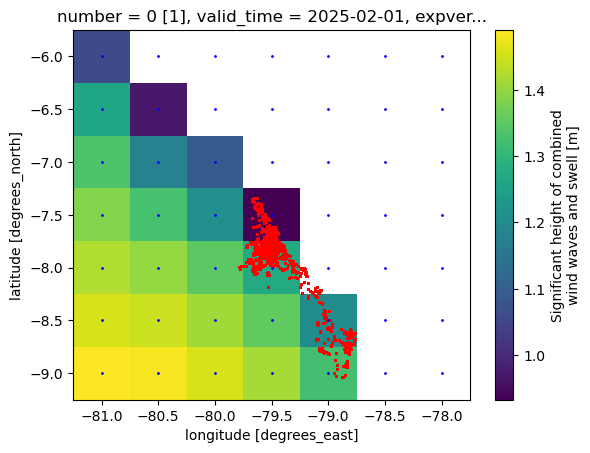

In [29]:
era5_wave.isel(valid_time=0).swh.plot()
plt.plot(data_40s_df['lon'], data_40s_df['lat'], 'o', color='red', markersize=1)

lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

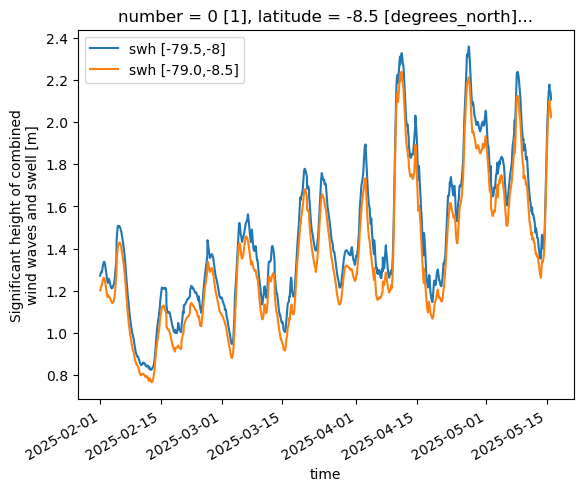

In [166]:
era5_wave.isel(longitude=3, latitude=4).swh.plot(label='swh [-79.5,-8]')
era5_wave.isel(longitude=4, latitude=5).swh.plot(label='swh [-79.0,-8.5]')
plt.legend()

### (3) plot chunk spectrum and era5 wave spectrum

In [167]:
swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_better:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    # accx_rotated,accy_rotated,accz_rotated = rotation_3d(accx_1, accy_1, accz_1)
    accz_rotated, accx_rotated, accy_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    accz_1_detrended = signal.detrend(accz_rotated)
    accx_1_detrended = signal.detrend(accx_rotated)
    accy_1_detrended = signal.detrend(accy_rotated)
    f_accz, Pxx_accz = power_spectral_density_fft(accz_1_detrended)
    f_accx, Pxx_accx = power_spectral_density_fft(accx_1_detrended)
    f_accy, Pxx_accy = power_spectral_density_fft(accy_1_detrended)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1))

    Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    # if icount == 0:
    #     PSD_acc = [Pxx_accz]
    #     f_accz_all = [f_accz]
    #     PSD_eta = [Pxx_eta]
    #     t_april = [chunk00['original_time'].iloc[0]]
    #     x_april = [chunk00['lon'].iloc[0]]
    #     y_april = [chunk00['lat'].iloc[0]]
    # else:
    #     PSD_acc.append(Pxx_accz)
    #     f_accz_all.append(f_accz)
    #     PSD_eta.append(Pxx_eta)
    #     t_april.append(chunk00['original_time'].iloc[0])
    #     x_april.append(chunk00['lon'].iloc[0])
    #     y_april.append(chunk00['lat'].iloc[0])
    # icount += 1

    fig = plt.figure(figsize=(12,9),constrained_layout=True)

    gs = fig.add_gridspec(3, 3, width_ratios=[3, 1, 1])
    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])
    axs3 = fig.add_subplot(gs[0,2])
    axs1.plot(np.arange(len(accz_1))/5,accz_1,label = 'RAW accz')
    # axs1.plot(np.arange(len(accz_1))/5,accz_rotated,label = 'Rotated accz')
    axs1.set_xlabel('Time [s]')
    axs1.set_ylabel('accz [m/s^2]')
    axs1.legend()
    axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs1.set_ylim(3,15)

    # axs2.plot(f_accz, Pxx_accz,label='RAW accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs2.axvline(x=0.05, color='r', linestyle='--')
    axs2.axvline(x=0.2, color='r', linestyle='--')
    axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(da.frequency, mean_power[0].values*da.frequency**2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    axs2.set_title(f'SH = {swh_chunk:.2f} m')
    axs2.set_ylim(0,8)
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.set_ylim(0,300)
    axs3.legend()

    axs4 = fig.add_subplot(gs[1,0])
    axs5 = fig.add_subplot(gs[1,1])
    axs6 = fig.add_subplot(gs[1,2])
    axs4.plot(np.arange(len(accz_1))/5,accx_1,label = 'RAW accx')
    # axs4.plot(np.arange(len(accz_1))/5,accx_rotated,label = 'Rotated accx')
    axs4.set_xlabel('Time [s]')
    axs4.set_ylabel('accx [m/s^2]')
    axs4.legend()
    # axs4.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs4.set_ylim(-5,5)

    # axs5.plot(f_accx, Pxx_accx,label='RAW accx (FFT)')
    axs5.plot(f_accx_detrend, Pxx_accx_detrend,label='Non-rot accx (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs5.axvline(x=0.05, color='r', linestyle='--')
    # axs5.axvline(x=0.2, color='r', linestyle='--')
    axs5.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs5.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs5.set_xscale('log')
    axs5.set_xlabel('Freq [Hz]')
    axs5.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs5.legend()
    # axs52 = axs5.twinx()
    # axs5.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs52.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs6.plot(f_accx, Pxx_x_eta,label='PSD x-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs6.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs6.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs6.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs6.set_xscale('log')
    axs6.set_xlabel('Freq [Hz]')
    axs6.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs6.set_yscale('log')
    # axs3.legend()

    axs7 = fig.add_subplot(gs[2,0])
    axs8 = fig.add_subplot(gs[2,1])
    axs9 = fig.add_subplot(gs[2,2])
    axs7.plot(np.arange(len(accz_1))/5,accy_1,label = 'RAW accy')
    # axs7.plot(np.arange(len(accz_1))/5,accy_rotated,label = 'Rotated accy')
    axs7.set_xlabel('Time [s]')
    axs7.set_ylabel('accy [m/s^2]')
    axs7.legend()
    axs7.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    axs7.set_ylim(-5,5)

    # axs8.plot(f_accx, Pxx_accy,label='RAW accy (FFT)')
    axs8.plot(f_accy_detrend, Pxx_accy_detrend,label='Non-rot accy (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs8.axvline(x=0.05, color='r', linestyle='--')
    # axs8.axvline(x=0.2, color='r', linestyle='--')
    axs8.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs8.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs8.set_xscale('log')
    axs8.set_xlabel('Freq [Hz]')
    axs8.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs82 = axs8.twinx()
    # axs8.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs82.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs9.plot(f_accx, Pxx_y_eta,label='PSD y-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs9.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs9.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs9.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs9.set_xscale('log')
    axs9.set_xlabel('Freq [Hz]')
    axs9.set_ylabel('Power spectral density [m**2/Hz]')
    # axs9.set_yscale('log')
    # axs9.legend()

    # print(np.std(accz_1))   
    # print(np.std(accz_1_filtered_1s))
    fig.savefig(f'chunk_spectrum_100s_v3/chunk_with_era5_2025-02-18_{i}.png')
    plt.close()

/tmp/ipykernel_21804/2407499243.py:28: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
/tmp/ipykernel_21804/2407499243.py:30: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
/tmp/ipykernel_21804/2407499243.py:32: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
/tmp/ipykernel_21804/2407499243.py:28: RuntimeWarning: invalid value encountered in divide
  Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
/tmp/ipykernel_21804/2407499243.py:30: RuntimeWarning: invalid value encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4


In [33]:
swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)

print(chunk00.iloc[0].original_time)
print(swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values)

2025-05-11 14:27:30.200000
1.5951948


### (4) plot rotated chunk with the wave spectrum


In [169]:

swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_better:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    accx_rotated_nosmoo,accy_rotated_nosmoo,accz_rotated_nosmoo = rotation_3d(accx_1, accy_1, accz_1)
    # accz_rotated, accx_rotated, accy_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    accz_1_detrended = signal.detrend(accz_rotated_nosmoo)
    accx_1_detrended = signal.detrend(accx_rotated_nosmoo)
    accy_1_detrended = signal.detrend(accy_rotated_nosmoo)
    f_accz_smoo, Pxx_accz_smoo = power_spectral_density_fft(accz_1_detrended)
    f_accx, Pxx_accx = power_spectral_density_fft(accx_1_detrended)
    f_accy, Pxx_accy = power_spectral_density_fft(accy_1_detrended)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1))

    Pxx_z_eta = Pxx_accz_smoo/(2*np.pi*f_accz_smoo)**4
    Pxx_z_eta = np.where(f_accz_smoo>0, Pxx_z_eta, 0)
    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)
    Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
    Pxx_x_eta_d = np.where(f_accx_detrend>0, Pxx_x_eta_d, 0)
    Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
    Pxx_y_eta_d = np.where(f_accy_detrend>0, Pxx_y_eta_d, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values

    diff_accz_rolling_avg = pd.Series(accz_rotated_nosmoo-accz_1).rolling(50,center=True).mean()
    diff_accz_rolling_avg = diff_accz_rolling_avg.values
    diff_accx_rolling_avg = pd.Series(accx_rotated_nosmoo-accx_1).rolling(50,center=True).mean()
    diff_accx_rolling_avg = diff_accx_rolling_avg.values
    diff_accy_rolling_avg = pd.Series(accy_rotated_nosmoo-accy_1).rolling(50,center=True).mean()
    diff_accy_rolling_avg = diff_accy_rolling_avg.values
    # if icount == 0:
    #     PSD_acc = [Pxx_accz]
    #     f_accz_all = [f_accz]
    #     PSD_eta = [Pxx_eta]
    #     t_april = [chunk00['original_time'].iloc[0]]
    #     x_april = [chunk00['lon'].iloc[0]]
    #     y_april = [chunk00['lat'].iloc[0]]
    # else:
    #     PSD_acc.append(Pxx_accz)
    #     f_accz_all.append(f_accz)
    #     PSD_eta.append(Pxx_eta)
    #     t_april.append(chunk00['original_time'].iloc[0])
    #     x_april.append(chunk00['lon'].iloc[0])
    #     y_april.append(chunk00['lat'].iloc[0])
    # icount += 1

    fig = plt.figure(figsize=(12,9),constrained_layout=True)

    gs = fig.add_gridspec(3, 3, width_ratios=[3, 1, 1])
    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])
    axs3 = fig.add_subplot(gs[0,2])
    # axs1.plot(np.arange(len(accz_1))/5,accz_1,label = 'RAW accz')
    # axs1.plot(np.arange(len(accz_1))/5,accz_rotated_nosmoo,label = 'Rotated accz')
    axs1.plot(np.arange(len(accz_1))/5,accz_rotated_nosmoo-accz_1,label = 'diff accz')
    axs1.plot(np.arange(len(accz_1))/5,diff_accz_rolling_avg,label = 'diff accz rolling avg')
    axs1.set_xlabel('Time [s]')
    axs1.set_ylabel('accz [m/s^2]')
    axs1.legend()
    axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs1.set_ylim(-1,2)

    axs2.plot(f_accz_smoo, Pxx_accz_smoo,label='Rotated accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs2.axvline(x=0.05, color='r', linestyle='--')
    axs2.axvline(x=0.2, color='r', linestyle='--')
    axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(da.frequency, mean_power[0].values*da.frequency**2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    axs2.set_title(f'SH = {swh_chunk:.2f} m')
    axs2.set_ylim(0,8)
    # axs2.set_yscale('log')
    axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs3.plot(f_accz_smoo, Pxx_z_eta,label='PSD eta')
    axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.set_ylim(0,300)
    axs3.legend()

    axs4 = fig.add_subplot(gs[1,0])
    axs5 = fig.add_subplot(gs[1,1])
    axs6 = fig.add_subplot(gs[1,2])
    # axs4.plot(np.arange(len(accz_1))/5,accx_1,label = 'Rotated accx')
    # axs4.plot(np.arange(len(accz_1))/5,accx_rotated,label = 'Raw accx')
    axs4.plot(np.arange(len(accz_1))/5,accx_rotated_nosmoo-accx_1,label = 'diff accx')
    axs4.plot(np.arange(len(accz_1))/5,diff_accx_rolling_avg,label = 'diff accx rolling avg')
    axs4.set_xlabel('Time [s]')
    axs4.set_ylabel('accx [m/s^2]')
    axs4.legend()
    # axs4.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs4.set_ylim(-5,5)

    axs5.plot(f_accx, Pxx_accx,label='Rotated accx (FFT)')
    axs5.plot(f_accx_detrend, Pxx_accx_detrend,label='Non-rot accx (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs5.axvline(x=0.05, color='r', linestyle='--')
    # axs5.axvline(x=0.2, color='r', linestyle='--')
    axs5.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs5.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs5.set_xscale('log')
    axs5.set_xlabel('Freq [Hz]')
    axs5.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    axs5.legend()
    # axs52 = axs5.twinx()
    # axs5.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs52.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs6.plot(f_accx, Pxx_x_eta,label='PSD x-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs6.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs6.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs6.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs6.set_xscale('log')
    axs6.set_xlabel('Freq [Hz]')
    axs6.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs6.set_yscale('log')
    # axs3.legend()

    axs7 = fig.add_subplot(gs[2,0])
    axs8 = fig.add_subplot(gs[2,1])
    axs9 = fig.add_subplot(gs[2,2])
    # axs7.plot(np.arange(len(accz_1))/5,accy_1,label = 'Rotated accy')
    # axs7.plot(np.arange(len(accz_1))/5,accy_rotated,label = 'Raw accy')
    axs7.plot(np.arange(len(accz_1))/5,accy_rotated_nosmoo-accy_1,label = 'diff accy')
    axs7.plot(np.arange(len(accz_1))/5,diff_accy_rolling_avg,label = 'diff accy rolling avg')
    axs7.set_xlabel('Time [s]')
    axs7.set_ylabel('accy [m/s^2]')
    axs7.legend()
    axs7.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs7.set_ylim(-5,5)

    axs8.plot(f_accx, Pxx_accy,label='Rotated accy (FFT)')
    axs8.plot(f_accy_detrend, Pxx_accy_detrend,label='Non-rot accy (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs8.axvline(x=0.05, color='r', linestyle='--')
    # axs8.axvline(x=0.2, color='r', linestyle='--')
    axs8.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs8.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs8.set_xscale('log')
    axs8.set_xlabel('Freq [Hz]')
    axs8.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs82 = axs8.twinx()
    # axs8.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs82.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs9.plot(f_accx, Pxx_y_eta,label='PSD y-displacement')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs9.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs9.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs9.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs9.set_xscale('log')
    axs9.set_xlabel('Freq [Hz]')
    axs9.set_ylabel('Power spectral density [m**2/Hz]')
    # axs9.set_yscale('log')
    # axs9.legend()

    # print(np.std(accz_1))   
    # print(np.std(accz_1_filtered_1s))
    fig.savefig(f'chunk_spectrum_100s_v3/chunk_with_era5_rotate_mean_{i}.png')
    plt.close()

Mean acceleration: x = -3.0819, y = 2.0166, z = 9.1910
Mean vector: [-3.08189325  2.0165763   9.19103805], norm: 9.901506269990698
Rotation axis: [ 0.20366359  0.31125499 -0.        ], norm: 0.37196576063139764
Rotation angle: 21.84 degrees
Mean before rotation: x = -3.0819, y = 2.0166, z = 9.1910
Mean after rotation: x = 0.0000, y = -0.0000, z = 9.9015


/tmp/ipykernel_21804/201072301.py:28: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta = Pxx_accz_smoo/(2*np.pi*f_accz_smoo)**4
/tmp/ipykernel_21804/201072301.py:30: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_21804/201072301.py:32: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
/tmp/ipykernel_21804/201072301.py:34: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_21804/201072301.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
/tmp/ipykernel_21804/201072301.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = -3.0345, y = 1.8016, z = 9.2743
Mean vector: [-3.0344946   1.8016392   9.27429225], norm: 9.923031695143164
Rotation axis: [ 0.18156137  0.30580318 -0.        ], norm: 0.3556404251120148
Rotation angle: 20.83 degrees
Mean before rotation: x = -3.0345, y = 1.8016, z = 9.2743
Mean after rotation: x = -0.0000, y = -0.0000, z = 9.9230
Mean acceleration: x = -2.9266, y = 1.8332, z = 9.2999
Mean vector: [-2.92656825  1.83324375  9.29988   ], norm: 9.920350416352345
Rotation axis: [ 0.18479627  0.29500654 -0.        ], norm: 0.3481070521900232
Rotation angle: 20.37 degrees
Mean before rotation: x = -2.9266, y = 1.8332, z = 9.2999
Mean after rotation: x = 0.0000, y = -0.0000, z = 9.9204
Mean acceleration: x = -3.0693, y = 1.3367, z = 9.2795
Mean vector: [-3.06933645  1.3367106   9.2795406 ], norm: 9.864963011511971
Rotation axis: [ 0.13550082  0.31113512 -0.        ], norm: 0.339360480487567
Rotation angle: 19.84 degrees
Mean before rotation: x = -3.0693, y = 1.3367, z =

In [160]:

swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_better:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    t_acc = np.arange(len(accz_1))/5
    # accx_rotated_nosmoo,accy_rotated_nosmoo,accz_rotated_nosmoo = rotation_3d(accx_1, accy_1, accz_1)
    accx_rotated, accy_rotated,accz_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    accz_1_detrended = signal.detrend(accz_rotated[50:-51])
    accx_1_detrended = signal.detrend(accx_rotated[50:-51])
    accy_1_detrended = signal.detrend(accy_rotated[50:-51])
    f_accz, Pxx_accz = power_spectral_density_fft(accz_1_detrended)
    f_accx, Pxx_accx = power_spectral_density_fft(accx_1_detrended)
    f_accy, Pxx_accy = power_spectral_density_fft(accy_1_detrended)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1))

    Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)
    Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
    Pxx_x_eta_d = np.where(f_accx_detrend>0, Pxx_x_eta_d, 0)
    Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
    Pxx_y_eta_d = np.where(f_accy_detrend>0, Pxx_y_eta_d, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values
    mwp_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    diff_accz_rolling_avg = pd.Series(accz_rotated[50:-50]-accz_1[50:-50]).rolling(50,center=True).mean()
    diff_accz_rolling_avg = diff_accz_rolling_avg.values
    diff_accx_rolling_avg = pd.Series(accx_rotated[50:-50]-accx_1[50:-50]).rolling(50,center=True).mean()
    diff_accx_rolling_avg = diff_accx_rolling_avg.values
    diff_accy_rolling_avg = pd.Series(accy_rotated[50:-50]-accy_1[50:-50]).rolling(50,center=True).mean()
    diff_accy_rolling_avg = diff_accy_rolling_avg.values
    if icount == 0:
        PSD_acc = [Pxx_accz]
        f_accz_all = [f_accz]
        PSD_eta = [Pxx_z_eta]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        mwp_all2 = [mwp_chunk2]
        swh_all2 = [swh_chunk2]
        mwd_all2 = [mwd_chunk2]
        chunk_id_all = [i]
    else:
        PSD_acc.append(Pxx_accz)
        f_accz_all.append(f_accz)
        PSD_eta.append(Pxx_z_eta)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        mwp_all2.append(mwp_chunk2)
        swh_all2.append(swh_chunk2)
        mwd_all2.append(mwd_chunk2)
        chunk_id_all.append(i)
    icount += 1

    fig = plt.figure(figsize=(12,9),constrained_layout=True)

    gs = fig.add_gridspec(3, 3, width_ratios=[3, 1, 1])
    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])
    axs3 = fig.add_subplot(gs[0,2])
    # axs1.plot(np.arange(len(accz_1[50:-51]))/5,accz_1[50:-51],label = 'RAW accz')
    # axs1.plot(np.arange(len(accz_1[50:-51]))/5,accz_rotated[50:-51],label = 'Rotated accz')
    axs1.plot(t_acc[50:-50],accz_rotated[50:-50]-accz_1[50:-50],label = 'diff accz')
    axs1.plot(t_acc[50:-50],diff_accz_rolling_avg,label = 'diff accz rolling avg')
    axs1.set_xlabel('Time [s]')
    axs1.set_ylabel('accz [m/s^2]')
    axs1.legend()
    axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs1.set_ylim(-1,2)

    axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs2.axvline(x=0.05, color='r', linestyle='--')
    axs2.axvline(x=0.2, color='r', linestyle='--')
    axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(da.frequency, mean_power[0].values*da.frequency**2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    axs2.set_title(f'SH = {swh_chunk:.2f} m')
    axs2.set_ylim(0,8)
    # axs2.set_yscale('log')
    axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
    axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.set_ylim(0,50)
    axs3.legend()

    axs4 = fig.add_subplot(gs[1,0])
    axs5 = fig.add_subplot(gs[1,1])
    axs6 = fig.add_subplot(gs[1,2])
    # axs4.plot(np.arange(len(accz_1))/5,accx_1,label = 'Rotated accx')
    # axs4.plot(np.arange(len(accz_1))/5,accx_rotated,label = 'Raw accx')
    axs4.plot(t_acc[50:-50],accx_rotated[50:-50]-accx_1[50:-50],label = 'diff accx')
    axs4.plot(t_acc[50:-50],diff_accx_rolling_avg,label = 'diff accx rolling avg')
    axs4.set_xlabel('Time [s]')
    axs4.set_ylabel('accx [m/s^2]')
    axs4.legend()
    # axs4.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs4.set_ylim(-5,5)

    axs5.plot(f_accx, Pxx_accx,label='Rotated accx (FFT)')
    axs5.plot(f_accx_detrend, Pxx_accx_detrend,label='Non-rot accx (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs5.axvline(x=0.05, color='r', linestyle='--')
    # axs5.axvline(x=0.2, color='r', linestyle='--')
    axs5.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs5.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs5.set_xscale('log')
    axs5.set_xlabel('Freq [Hz]')
    axs5.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    axs5.legend()
    # axs52 = axs5.twinx()
    # axs5.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs52.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs6.plot(f_accx, Pxx_x_eta,label='PSD x-displacement')
    axs6.plot(f_accx_detrend, Pxx_x_eta_d,label='FFT eta')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs6.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs6.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs6.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs6.set_xscale('log')
    axs6.set_xlabel('Freq [Hz]')
    axs6.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs6.set_yscale('log')
    # axs3.legend()
    axs6.set_ylim(0,50)

    axs7 = fig.add_subplot(gs[2,0])
    axs8 = fig.add_subplot(gs[2,1])
    axs9 = fig.add_subplot(gs[2,2])
    # axs7.plot(np.arange(len(accz_1))/5,accy_1,label = 'Rotated accy')
    # axs7.plot(np.arange(len(accz_1))/5,accy_rotated,label = 'Raw accy')
    axs7.plot(t_acc[50:-50],accy_rotated[50:-50]-accy_1[50:-50],label = 'diff accy')
    axs7.plot(t_acc[50:-50],diff_accy_rolling_avg,label = 'diff accy rolling avg')
    axs7.set_xlabel('Time [s]')
    axs7.set_ylabel('accy [m/s^2]')
    axs7.legend()
    axs7.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs7.set_ylim(-5,5)

    axs8.plot(f_accx, Pxx_accy,label='Rotated accy (FFT)')
    axs8.plot(f_accy_detrend, Pxx_accy_detrend,label='Non-rot accy (FFT)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    # axs8.axvline(x=0.05, color='r', linestyle='--')
    # axs8.axvline(x=0.2, color='r', linestyle='--')
    axs8.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs8.plot(da.frequency, mean_power[0])
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs8.set_xscale('log')
    axs8.set_xlabel('Freq [Hz]')
    axs8.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs2.set_yscale('log')
    # axs2.legend()
    # axs82 = axs8.twinx()
    # axs8.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'orange',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs82.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    axs9.plot(f_accx, Pxx_y_eta,label='PSD y-displacement')
    axs9.plot(f_accy_detrend, Pxx_y_eta_d,label='FFT eta')
    # axs3.plot(f_accz_fft[1:], Pxx_eta_fft[1:],label='FFT eta')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs9.axvline(x=0.05, color='r', linestyle='--', label='0.05 Hz')
    axs9.axvline(x=0.2, color='r', linestyle='--', label='0.2 Hz')
    axs9.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs9.set_xscale('log')
    axs9.set_xlabel('Freq [Hz]')
    axs9.set_ylabel('Power spectral density [m**2/Hz]')
    # axs9.set_yscale('log')
    # axs9.legend()
    axs9.set_ylim(0,50)

    # print(np.std(accz_1))   
    # print(np.std(accz_1_filtered_1s))
    fig.savefig(f'chunk_spectrum_100s_v3/chunk_with_era5_moving_rotate_{i}.png')
    plt.close()

/tmp/ipykernel_21804/1956294997.py:30: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
/tmp/ipykernel_21804/1956294997.py:32: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_21804/1956294997.py:34: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
/tmp/ipykernel_21804/1956294997.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_21804/1956294997.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
/tmp/ipykernel_21804/1956294997.py:40: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
/tmp/ipykernel_21804/1956294997.py:34: RuntimeWarning: invalid value encountered in divide
  Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4


Text(0.5, 1.0, 'chunk id=8557 accz_time=2025-05-04T14:27:53.200000000')

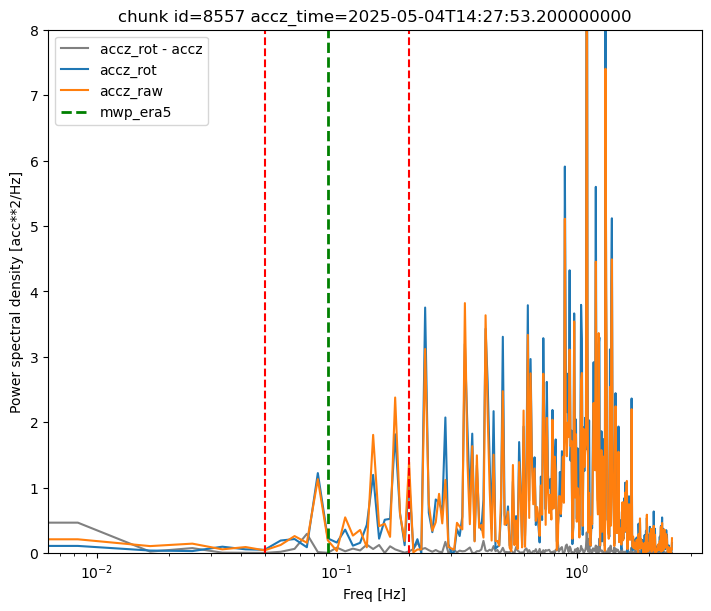

In [111]:
diff_accz = accz_rotated_nosmoo-accz_1
f_accz_diff, Pxx_accz_diff = power_spectral_density_fft(signal.detrend(diff_accz))

fig = plt.figure(figsize=(7,6),constrained_layout=True)
plt.plot(f_accz_diff, Pxx_accz_diff,label='accz_rot - accz', color = 'grey')
plt.plot(f_accz_smoo, Pxx_accz_smoo,label='accz_rot', color = 'tab:blue')
plt.plot(f_accz_detrend, Pxx_accz_detrend,label='accz_raw', color = 'C1')
plt.axvline(x=0.05, color='r', linestyle='--')
plt.axvline(x=0.2, color='r', linestyle='--')
plt.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp_era5',linewidth=2)
plt.xscale('log')
plt.ylim(0,8)
plt.xlabel('Freq [Hz]')
plt.ylabel('Power spectral density [acc**2/Hz]')
plt.legend()
plt.title(f'chunk id={i} accz_time={chunk00["original_time"].values[0]}')



Text(0.5, 1.0, 'chunk id=8557 accz_time=2025-05-04T14:27:53.200000000')

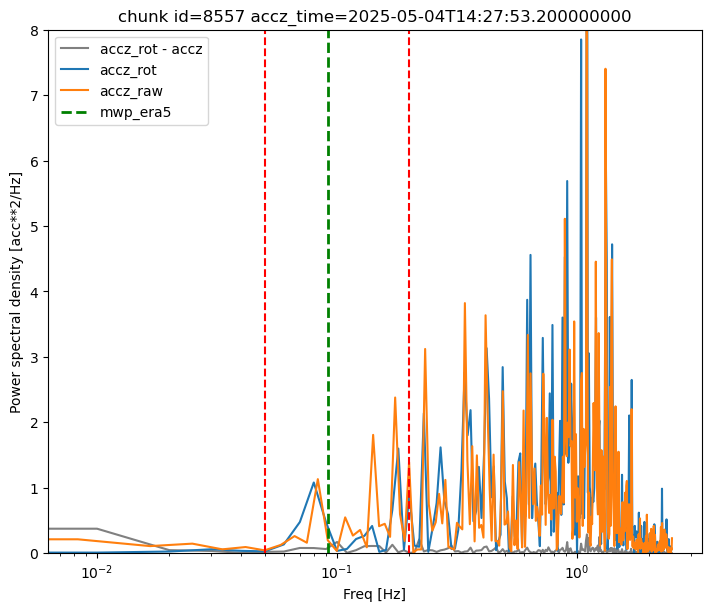

In [112]:
diff_accz = accz_rotated[50:-51]-accz_1[50:-51]
f_accz_diff, Pxx_accz_diff = power_spectral_density_fft(signal.detrend(diff_accz))

fig = plt.figure(figsize=(7,6),constrained_layout=True)
plt.plot(f_accz_diff, Pxx_accz_diff,label='accz_rot - accz', color = 'grey')
plt.plot(f_accz, Pxx_accz,label='accz_rot', color = 'tab:blue')
plt.plot(f_accz_detrend, Pxx_accz_detrend,label='accz_raw', color = 'C1')
plt.axvline(x=0.05, color='r', linestyle='--')
plt.axvline(x=0.2, color='r', linestyle='--')
plt.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp_era5',linewidth=2)
plt.xscale('log')
plt.ylim(0,8)
plt.xlabel('Freq [Hz]')
plt.ylabel('Power spectral density [acc**2/Hz]')
plt.legend()
plt.title(f'chunk id={i} accz_time={chunk00["original_time"].values[0]}')



# get the Hs of the chunk and compare with the Hs of ERA5

## (1) plot directly

In [190]:
# # Create an array to store timestamps
# t_120s = np.empty(len(rec_list2_better), dtype='datetime64[ns]')
# x_120s = np.empty(len(rec_list2_better), dtype='float64')
# y_120s = np.empty(len(rec_list2_better), dtype='float64')
# hs_120s = np.empty(len(rec_list2_better), dtype='float64')


# icount=0
# for i in rec_list2_better:
#     chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]
#     t_120s[icount] = chunk00['original_time'].iloc[0]
#     x_120s[icount] = chunk00['lon'].iloc[0]
#     y_120s[icount] = chunk00['lat'].iloc[0]
#     icount += 1

# x_120s

m0 = np.zeros(len(PSD_eta))
m0_band = np.zeros(len(PSD_eta))
m0_band2 = np.zeros(len(PSD_eta))
Hs = np.zeros(len(PSD_eta))
Hs_band = np.zeros(len(PSD_eta))
Hs_band2 = np.zeros(len(PSD_eta))
for i in range(len(PSD_eta)):
    PSD_eta0 = PSD_eta[i]
    f_accz0 = f_accz_all[i]
    # Compute significant wave height
    # Integrate the PSD between 0.05 Hz and 0.2 Hz (typical wave frequency range)
    mask = (f_accz0 >= 0.05) & (f_accz0 <= 0.2)
    mask2 = (f_accz0 >= 0.05) & (f_accz0 <= 0.15)
    m0[i] = np.trapz(PSD_eta0, f_accz0)
    m0_band[i] = np.trapz(PSD_eta0[mask], f_accz0[mask])
    m0_band2[i] = np.trapz(PSD_eta0[mask2], f_accz0[mask2])
    Hs[i] = 4 * np.sqrt(m0[i])
    Hs_band[i] = 4 * np.sqrt(m0_band[i])
    Hs_band2[i] = 4 * np.sqrt(m0_band2[i])
    # print(f"Significant Wave Height: {Hs[i]:.2f} m, filtered: {Hs_band[i]:.2f} m")


In [191]:
# create a dataframe with the results
Hs_df = pd.DataFrame({
    'time': t_april,
    'Hs': Hs,
    'Hs_band': Hs_band,
    'Hs_band2': Hs_band2,
    'lon': x_april,
    'lat': y_april,
    'era5_wmp': mwp_all,
    'era5_swh': swh_all,
    'era5_mwd': mwd_all,
    'era5_wmp2': mwp_all2,
    'era5_swh2': swh_all2,
    'era5_mwd2': mwd_all2,
    'chunk_id': chunk_id_all,
})
Hs_df
# # Add date column for grouping
# Hs_df['date'] = pd.to_datetime(Hs_df['time']).dt.date

# # Group by date and calculate daily averages
# daily_Hs_df = Hs_df.groupby('date').agg({
#     'Hs': ['mean', 'std', 'min', 'max', 'count'],
#     'Hs_band': ['mean', 'std', 'min', 'max']
# })

# # Flatten the multi-level columns
# daily_Hs_df.columns = ['_'.join(col).strip('_') for col in daily_Hs_df.columns.values]

# # Reset index to make date a column
# daily_Hs_df = daily_Hs_df.reset_index()

,time,Hs,Hs_band,Hs_band2,lon,lat,era5_wmp,era5_swh,era5_mwd,era5_wmp2,era5_swh2,era5_mwd2,chunk_id
0,2025-05-04 14:27:53.200,10.687645,2.710428,2.653618,-79.61071014404298,-7.953651428222656,10.935384,1.8345642,198.56537,11.111165,1.743988,200.956,8557
1,2025-05-04 16:20:49.200,17.289946,2.016227,1.908689,-79.66694641113281,-8.025895118713379,10.947377,1.8283339,198.82312,11.08727,1.7350721,201.1278,8570
2,2025-05-04 17:36:19.200,31.189425,1.589872,1.456551,-79.64444732666014,-8.037311553955078,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8589
3,2025-05-04 18:10:01.200,17.144978,2.509395,2.405819,-79.64291381835938,-8.051445007324219,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8605
4,2025-05-05 13:21:47.200,14.098202,1.899266,1.811886,-79.4471435546875,-7.980865001678467,10.658159,1.6482477,200.12915,10.767046,1.5510798,202.25415,8639
5,2025-05-05 13:51:38.200,11.978876,1.465440,1.407366,-79.4229965209961,-8.005577087402344,10.696815,1.6422911,200.19464,10.837195,1.5441465,202.4212,8654
6,2025-05-05 14:35:27.200,27.770299,1.233340,1.086677,-79.40978240966798,-8.010111808776855,10.691909,1.6201448,200.31943,10.842055,1.5180941,202.62411,8655
7,2025-05-05 15:58:43.200,82.794146,3.056150,3.021383,-79.40791320800781,-8.026068687438965,10.7370825,1.6152229,200.43655,10.916526,1.5134163,202.82718,8677
8,2025-05-06 16:24:26.200,28.436325,4.009355,3.978314,-79.05322265625,-8.792440414428711,12.116164,1.7699013,204.73555,12.388381,1.6837196,206.94649,8787
9,2025-05-07 13:49:57.200,27.127613,1.503249,1.314138,-79.1109619140625,-8.683161735534668,12.63393,2.010641,204.76625,13.000874,1.9193325,207.11,8892


Text(0.5, 1.0, 'Hs from accz vs Hs from era5 (before conservation transformation)')

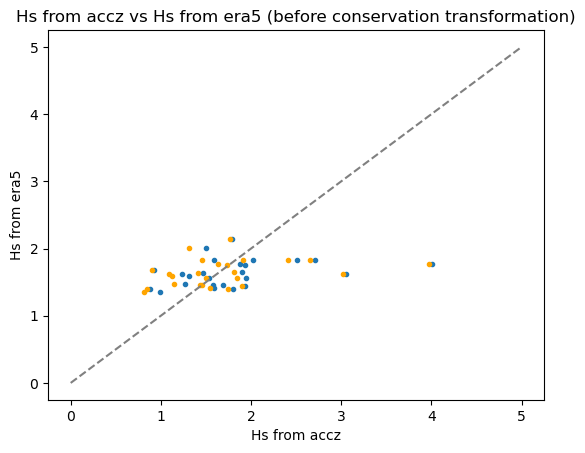

In [192]:
plt.plot(Hs_df['Hs_band'],Hs_df['era5_swh'],'.')
plt.plot(Hs_df['Hs_band2'],Hs_df['era5_swh'],'.',color='orange')
# plt.plot(Hs_df['Hs_band'],Hs_df['era5_swh2'],'.',color='orange')
plt.plot([0,5],[0,5],'--',color = 'grey')
plt.xlabel('Hs from accz')
plt.ylabel('Hs from era5')
plt.title('Hs from accz vs Hs from era5 (before conservation transformation)')

/tmp/ipykernel_21804/2249148483.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10,3),constrained_layout=True)


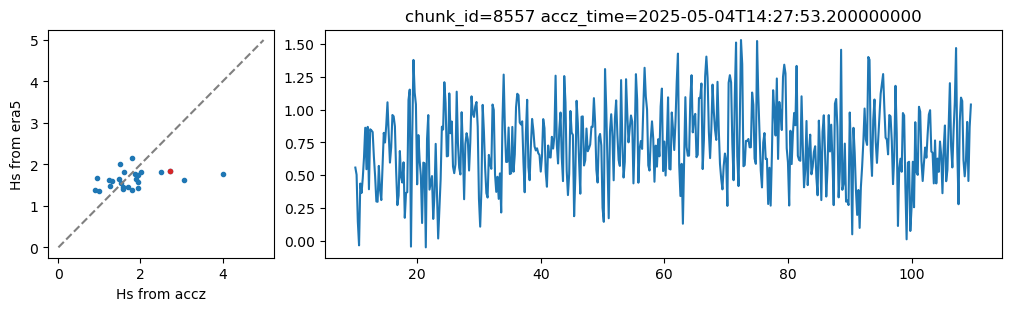

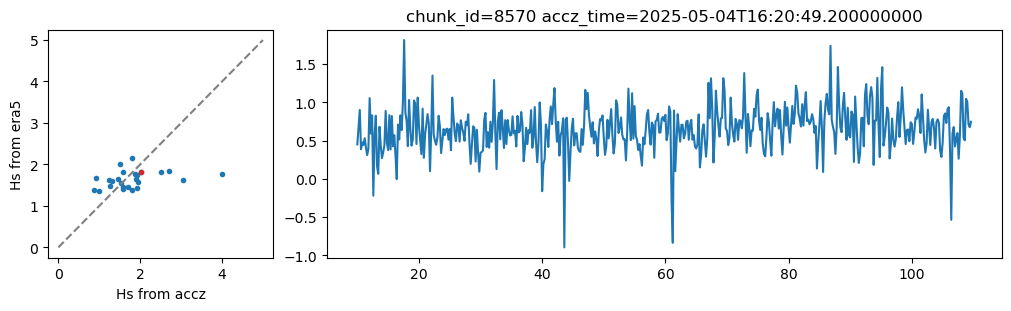

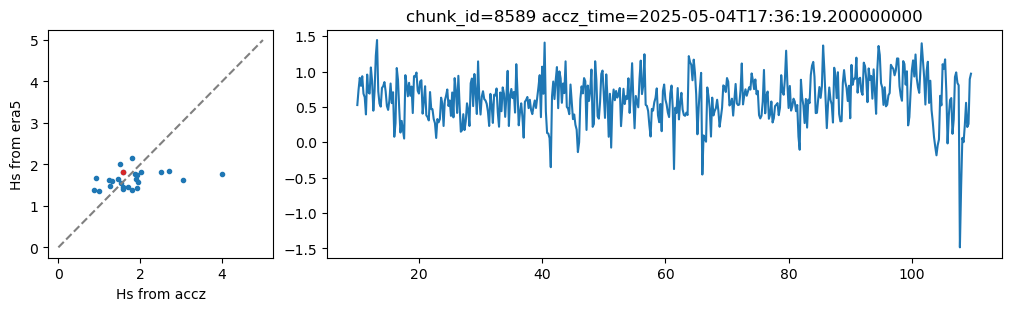

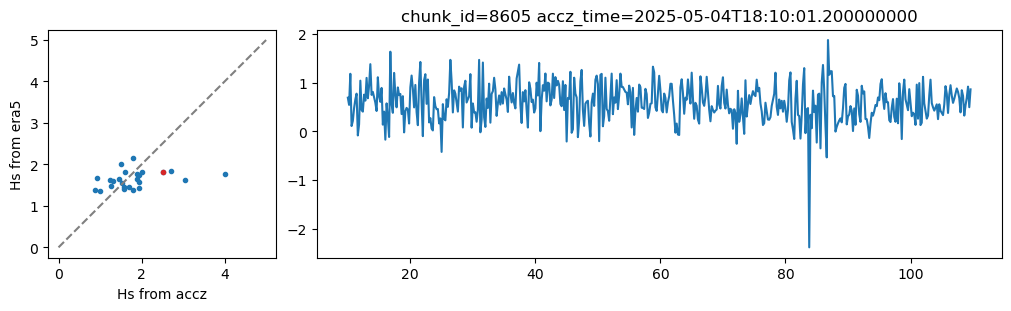

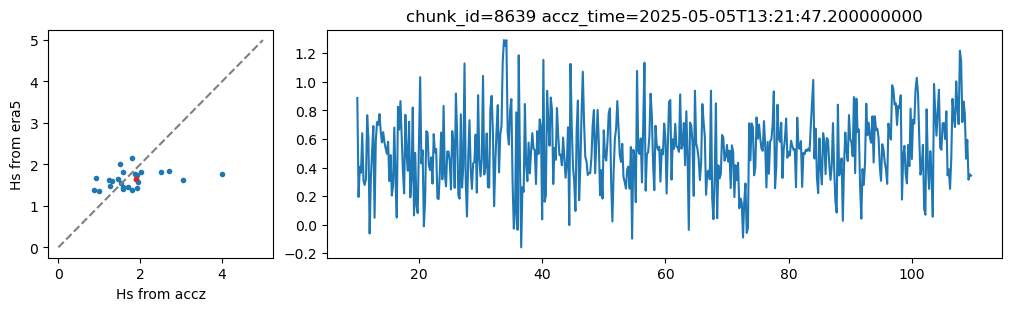

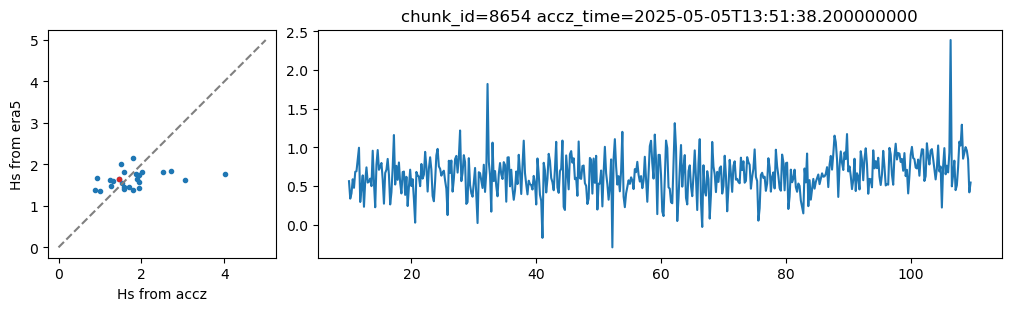

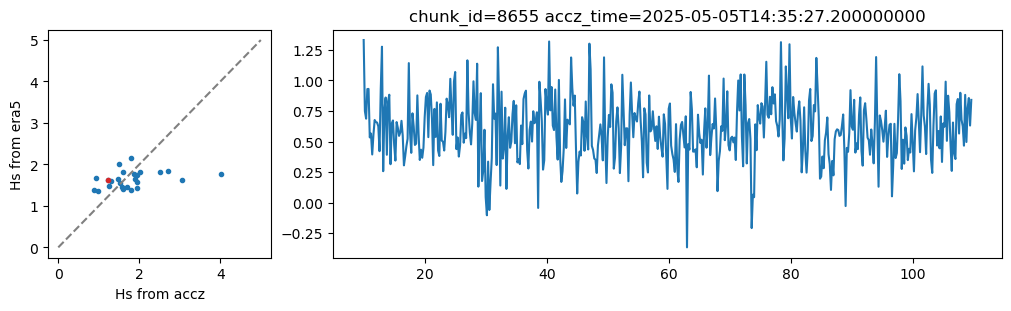

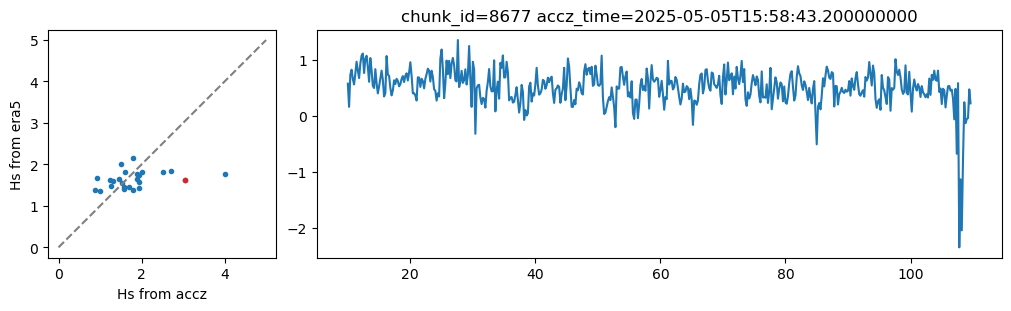

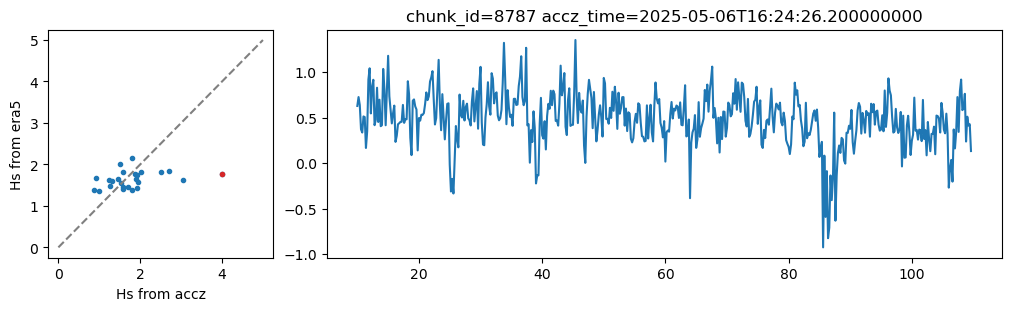

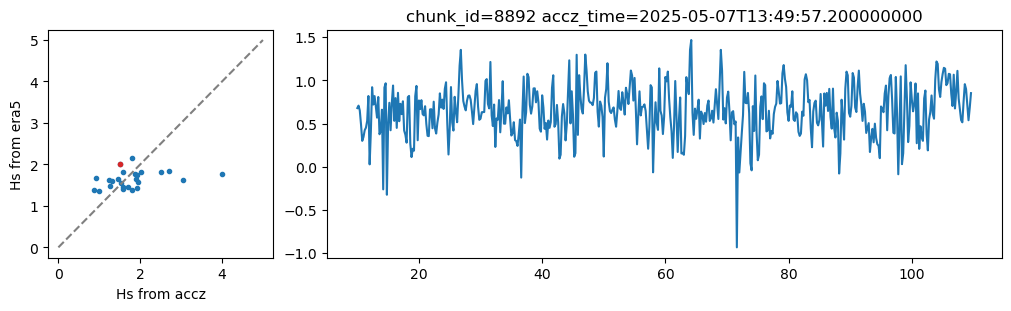

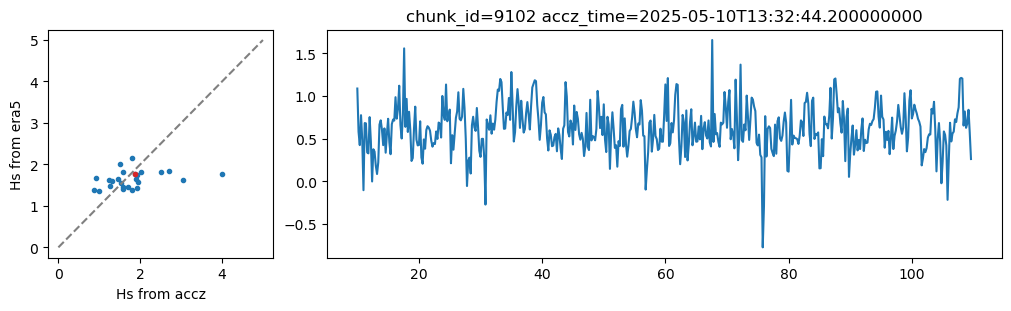

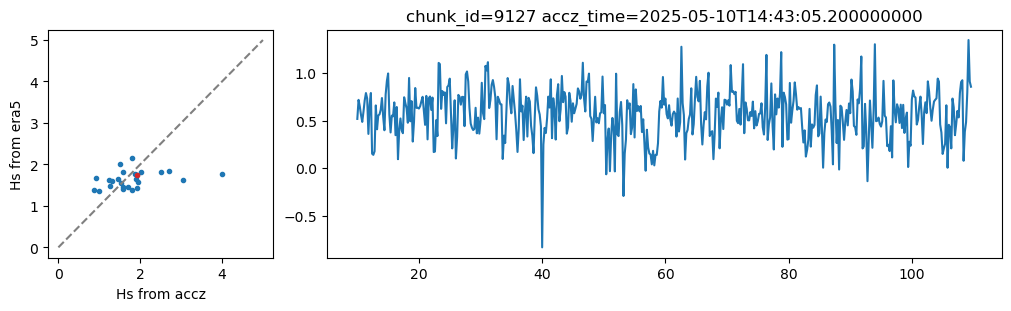

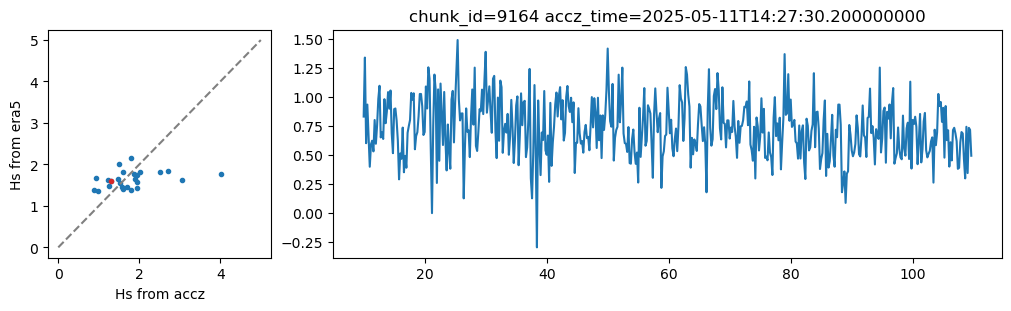

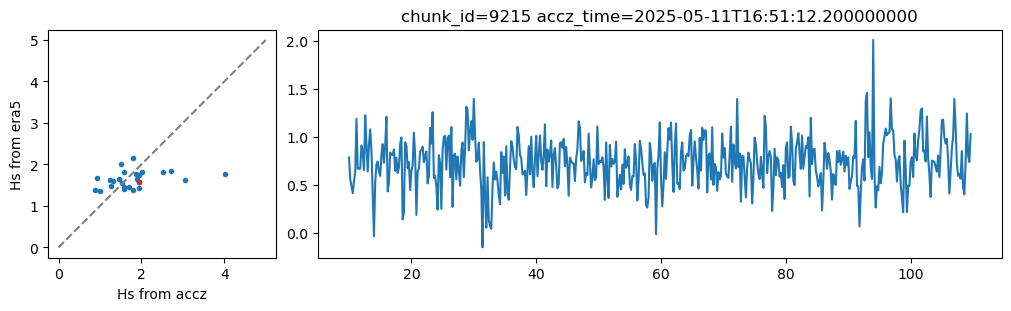

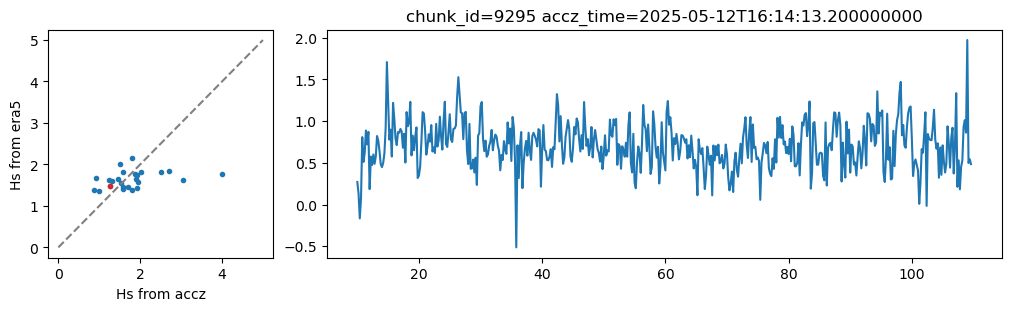

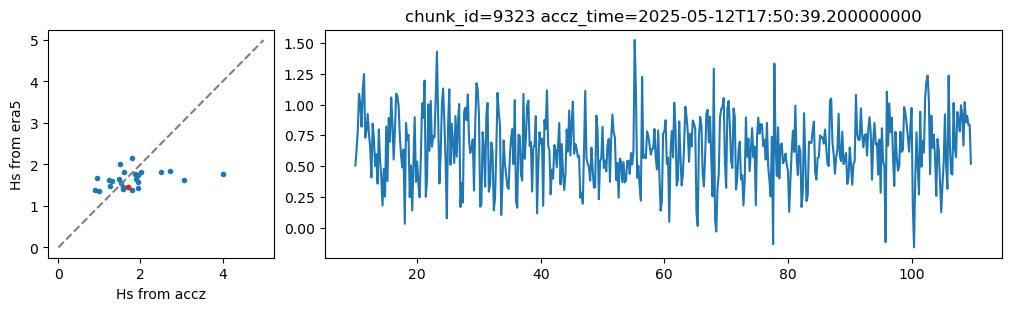

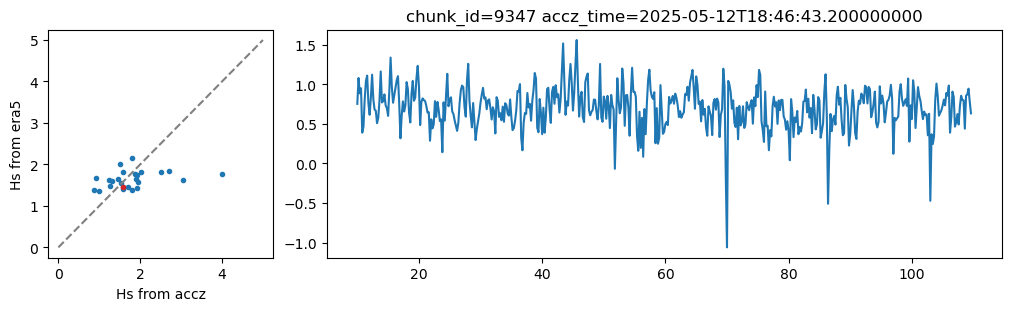

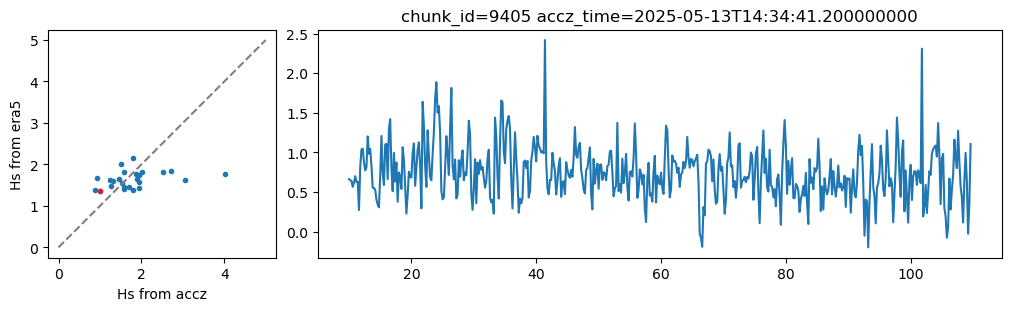

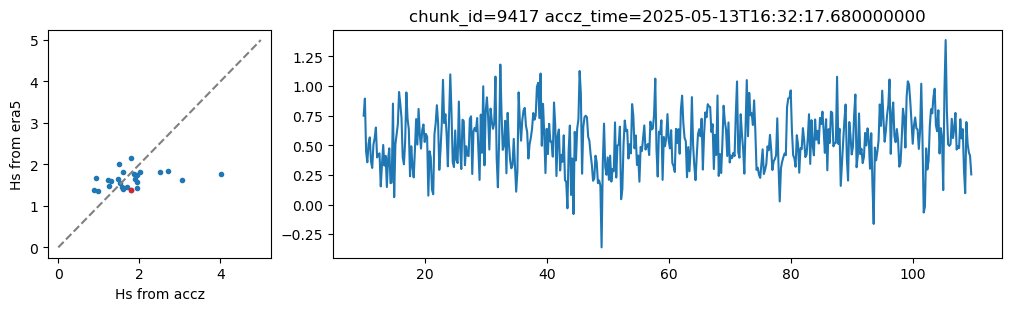

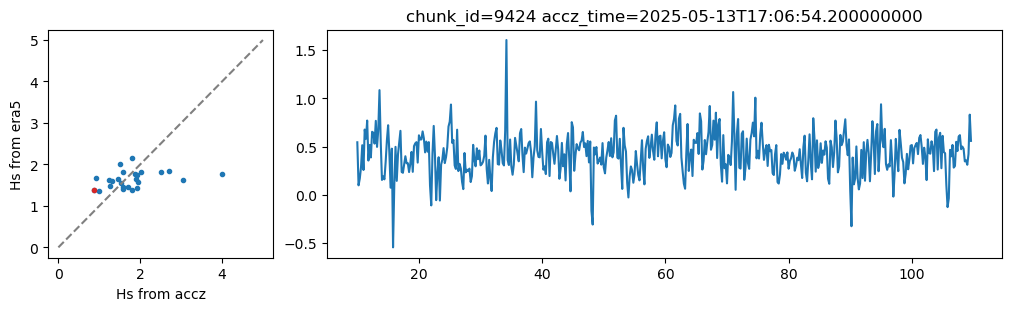

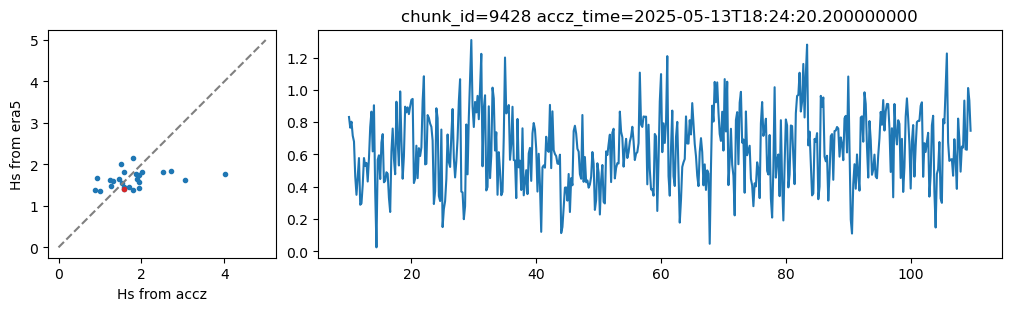

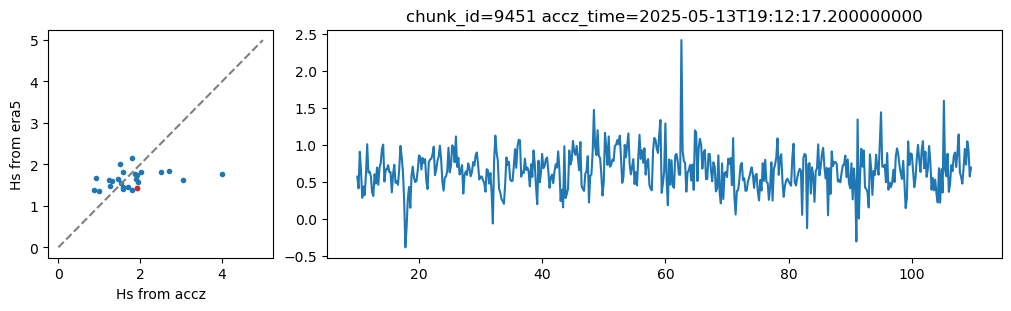

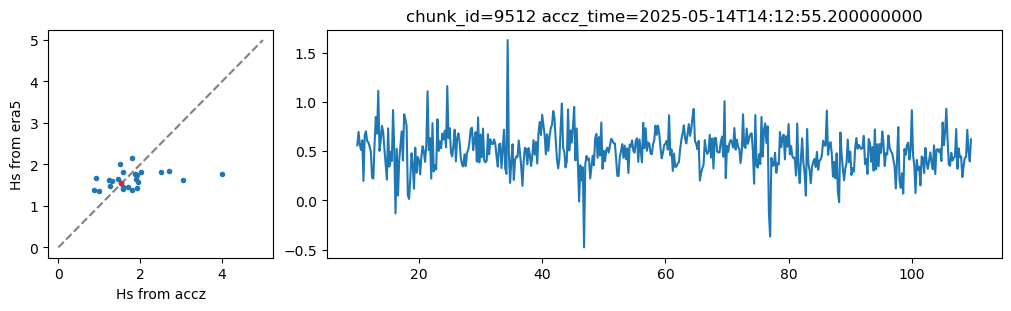

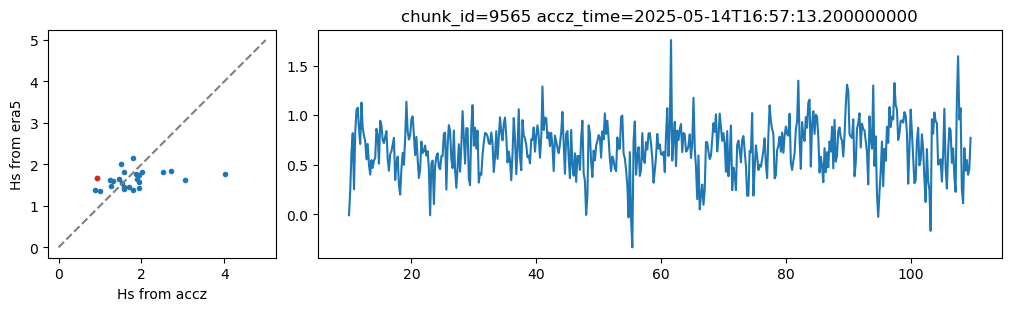

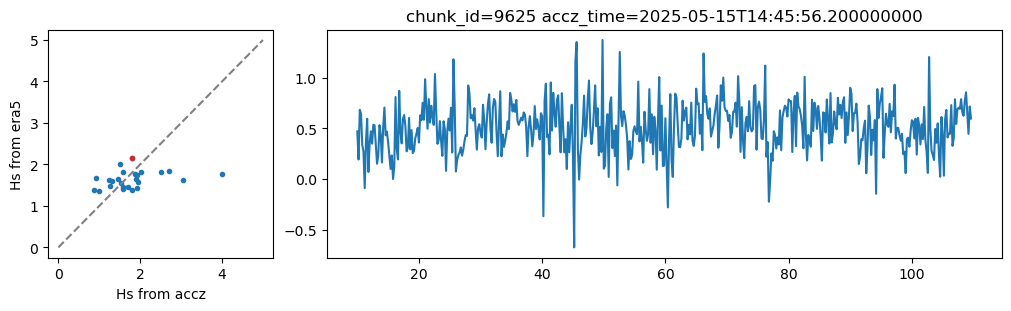

In [145]:
icount=0
for i in rec_list2_better:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    t_acc = np.arange(len(accz_1))/5
    accx_rotated, accy_rotated,accz_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)
    accz_1_detrended = signal.detrend(accz_rotated[50:-51])
    accx_1_detrended = signal.detrend(accx_rotated[50:-51])
    accy_1_detrended = signal.detrend(accy_rotated[50:-51])

    fig = plt.figure(figsize=(10,3),constrained_layout=True)

    gs = fig.add_gridspec(1, 2, width_ratios=[1,3])

    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])

    axs1.plot(Hs_df['Hs_band'],Hs_df['era5_swh'],'.',color= 'tab:blue')
    axs1.plot([0,5],[0,5],'--',color = 'grey')
    axs1.plot(Hs_df['Hs_band'].iloc[icount],Hs_df['era5_swh'].iloc[icount],'.',color= 'tab:red')
    axs1.set_xlabel('Hs from accz')
    axs1.set_ylabel('Hs from era5')

    # axs2.plot(t_acc,accz_1,label = 'RAW accz')
    # axs2.plot(t_acc[50:-51],accz_rotated[50:-51],label = 'Rotated accz')
    axs2.plot(t_acc[50:-51],(accz_rotated-accz_1)[50:-51],label = 'diff accz')
    axs2.set_title(f'chunk_id={i} accz_time={chunk00["original_time"].values[0]}')
    icount += 1


## (2) do energy conservation transformation

In [173]:
### interpolation bathymetry

# Get depths for all locations in Hs_df
depths = get_depths_at_locations(Hs_df['lon'], Hs_df['lat'], bath1_region)

# Add depths to the dataframe
Hs_df['depth'] = depths

# Print the updated dataframe
print(f"Added depths to {len(Hs_df)} locations")

Added depths to 25 locations


In [174]:
Hs_df

,time,Hs,Hs_band,lon,lat,era5_wmp,era5_swh,era5_mwd,era5_wmp2,era5_swh2,era5_mwd2,chunk_id,Hs0,depth
0,2025-05-04 14:27:53.200,10.687645,2.710428,-79.61071014404298,-7.953651428222656,10.935384,1.8345642,198.56537,11.111165,1.743988,200.956,8557,NaN,-81.963989
1,2025-05-04 16:20:49.200,17.289946,2.016227,-79.66694641113281,-8.025895118713379,10.947377,1.8283339,198.82312,11.08727,1.7350721,201.1278,8570,NaN,-103.419449
2,2025-05-04 17:36:19.200,31.189425,1.589872,-79.64444732666014,-8.037311553955078,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8589,NaN,-97.726135
3,2025-05-04 18:10:01.200,17.144978,2.509395,-79.64291381835938,-8.051445007324219,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8605,NaN,-85.153198
4,2025-05-05 13:21:47.200,14.098202,1.899266,-79.4471435546875,-7.980865001678467,10.658159,1.6482477,200.12915,10.767046,1.5510798,202.25415,8639,NaN,-37.351707
5,2025-05-05 13:51:38.200,11.978876,1.465440,-79.4229965209961,-8.005577087402344,10.696815,1.6422911,200.19464,10.837195,1.5441465,202.4212,8654,NaN,-40.696167
6,2025-05-05 14:35:27.200,27.770299,1.233340,-79.40978240966798,-8.010111808776855,10.691909,1.6201448,200.31943,10.842055,1.5180941,202.62411,8655,NaN,-38.628281
7,2025-05-05 15:58:43.200,82.794146,3.056150,-79.40791320800781,-8.026068687438965,10.7370825,1.6152229,200.43655,10.916526,1.5134163,202.82718,8677,NaN,-46.912140
8,2025-05-06 16:24:26.200,28.436325,4.009355,-79.05322265625,-8.792440414428711,12.116164,1.7699013,204.73555,12.388381,1.6837196,206.94649,8787,NaN,-77.000000
9,2025-05-07 13:49:57.200,27.127613,1.503249,-79.1109619140625,-8.683161735534668,12.63393,2.010641,204.76625,13.000874,1.9193325,207.11,8892,NaN,-71.130859


In [175]:
depth1 = 91
g=9.81

# Add the 'Hs0' column to the DataFrame if it doesn't exist
if 'Hs0' not in Hs_df.columns:
    Hs_df['Hs0'] = np.nan

for k in range(len(Hs_df)):
# for k in [3]:
    t_bird = Hs_df['time'].iloc[k]
    # h_bird = -Hs_df['depth'].iloc[k]
    h_bird = -Hs_df['depth'].iloc[k]

    # # depth1 = ds_era5_hor.wmb.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # swh1 = ds_era5_hor.swh.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwd1 = ds_era5_hor.mwd.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwp1 = ds_era5_hor.mwp.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # print(k,swh1,mwd1,mwp1)
    swh1 = Hs_df['era5_swh'].iloc[k]
    mwd1 = Hs_df['era5_mwd'].iloc[k]
    mwp1 = Hs_df['era5_wmp'].iloc[k]

    k1 = wavenumber(mwp1,depth1,g)
    cel1 = waveCel(k1,mwp1)
    n1 = nRatio(k1,depth1)
    cg1 = waveGroupSpeed(cel1,n1)

    k2 = wavenumber(mwp1,h_bird,g)
    cel2 = waveCel(k2,mwp1)
    n2 = nRatio(k2,h_bird)
    cg2 = waveGroupSpeed(cel2,n2)

    theta1 = 240-mwd1
    theta_bird = Snell(theta1,cel1,cel2)

    h2 = swh1*np.sqrt(cg1*np.cos(np.radians(theta1))/(cg2*np.cos(np.radians(theta_bird))))
    # print(k1,k2,cel1,cel2,n1,n2,cg1,cg2,theta1,theta_bird,h_bird,swh1,mwd1,mwp1,h2)
    print(depth1, h_bird,k1,k2,cel1, cel2, theta1,theta_bird,mwd1,cg1,cg2,h2)
    print(n1,n2)
    print(h2,swh1)
    # Hs_df.at[k, 'Hs'] = h2
    Hs_df.at[k, 'Hs0'] = h2

91 81.96398925782384 0.03379667279049503 0.0339131388913851 17.000899159289773 16.94251386965176 41.43463134765625 41.261177139687554 198.56537 8.723332224300954 8.834023044213136 1.8206076410035688
0.5131100503901452 0.521411586980434
1.8206076410035688 1.8345642
91 103.41944885253807 0.033724559918672806 0.03364309960650114 17.01858682757431 17.05979407101828 41.1768798828125 41.29834332451535 198.82312 8.734873193775746 8.642714587071993 1.839764556849567
0.5132549066661103 0.5066130664352221
1.839764556849567 1.8283339
91 97.72613525390739 0.034538681075430136 0.0344916566921447 16.821817883112736 16.844751997839484 41.28865051269531 41.35728448755292 198.71135 8.607815011511976 8.556478119476488 1.8347055816086977
0.5117053977949244 0.5079610623281331
1.8347055816086977 1.8282633
91 85.15319824218649 0.034538681075430136 0.03460072218915736 16.821817883112736 16.791655382148758 41.28865051269531 41.198494197979464 198.71135 8.607815011511976 8.668873359221944 1.8205570271047984
0.

In [176]:
Hs_df

,time,Hs,Hs_band,lon,lat,era5_wmp,era5_swh,era5_mwd,era5_wmp2,era5_swh2,era5_mwd2,chunk_id,Hs0,depth
0,2025-05-04 14:27:53.200,10.687645,2.710428,-79.61071014404298,-7.953651428222656,10.935384,1.8345642,198.56537,11.111165,1.743988,200.956,8557,1.820608,-81.963989
1,2025-05-04 16:20:49.200,17.289946,2.016227,-79.66694641113281,-8.025895118713379,10.947377,1.8283339,198.82312,11.08727,1.7350721,201.1278,8570,1.839765,-103.419449
2,2025-05-04 17:36:19.200,31.189425,1.589872,-79.64444732666014,-8.037311553955078,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8589,1.834706,-97.726135
3,2025-05-04 18:10:01.200,17.144978,2.509395,-79.64291381835938,-8.051445007324219,10.814369,1.8282633,198.71135,10.959389,1.7279215,201.1176,8605,1.820557,-85.153198
4,2025-05-05 13:21:47.200,14.098202,1.899266,-79.4471435546875,-7.980865001678467,10.658159,1.6482477,200.12915,10.767046,1.5510798,202.25415,8639,1.484333,-37.351707
5,2025-05-05 13:51:38.200,11.978876,1.465440,-79.4229965209961,-8.005577087402344,10.696815,1.6422911,200.19464,10.837195,1.5441465,202.4212,8654,1.494192,-40.696167
6,2025-05-05 14:35:27.200,27.770299,1.233340,-79.40978240966798,-8.010111808776855,10.691909,1.6201448,200.31943,10.842055,1.5180941,202.62411,8655,1.464815,-38.628281
7,2025-05-05 15:58:43.200,82.794146,3.056150,-79.40791320800781,-8.026068687438965,10.7370825,1.6152229,200.43655,10.916526,1.5134163,202.82718,8677,1.498050,-46.912140
8,2025-05-06 16:24:26.200,28.436325,4.009355,-79.05322265625,-8.792440414428711,12.116164,1.7699013,204.73555,12.388381,1.6837196,206.94649,8787,1.736355,-77.000000
9,2025-05-07 13:49:57.200,27.127613,1.503249,-79.1109619140625,-8.683161735534668,12.63393,2.010641,204.76625,13.000874,1.9193325,207.11,8892,1.947875,-71.130859


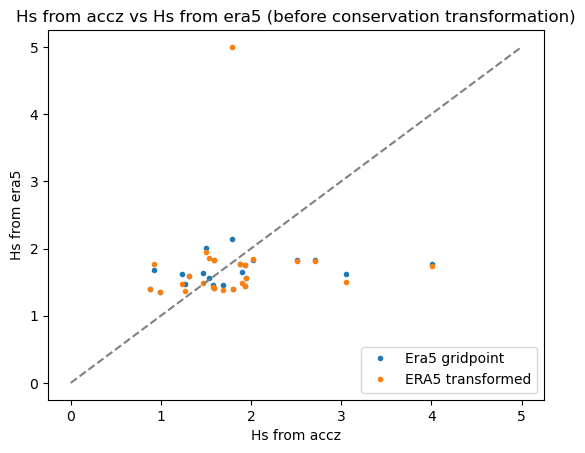

In [177]:
plt.plot(Hs_df['Hs_band'],Hs_df['era5_swh'],'.',color='tab:blue',label='Era5 gridpoint')
plt.plot(Hs_df['Hs_band'],Hs_df['Hs0'],'.',color='tab:orange',label='ERA5 transformed')
plt.plot([0,5],[0,5],'--',color = 'grey')
plt.xlabel('Hs from accz')
plt.ylabel('Hs from era5')
plt.title('Hs from accz vs Hs from era5 (before conservation transformation)')
plt.legend()

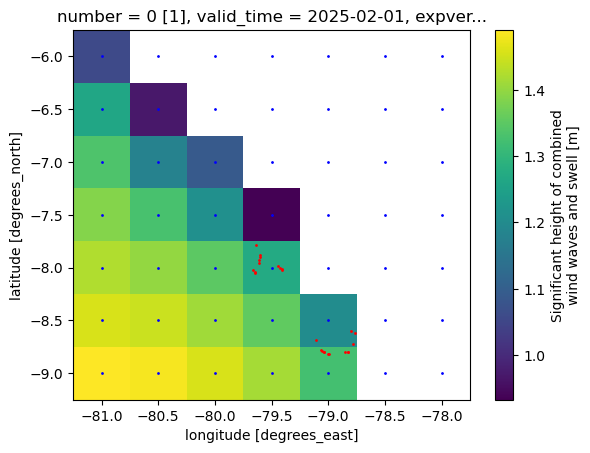

In [164]:
era5_wave.isel(valid_time=0).swh.plot()
plt.plot(Hs_df['lon'], Hs_df['lat'], 'o', color='red', markersize=1)

lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

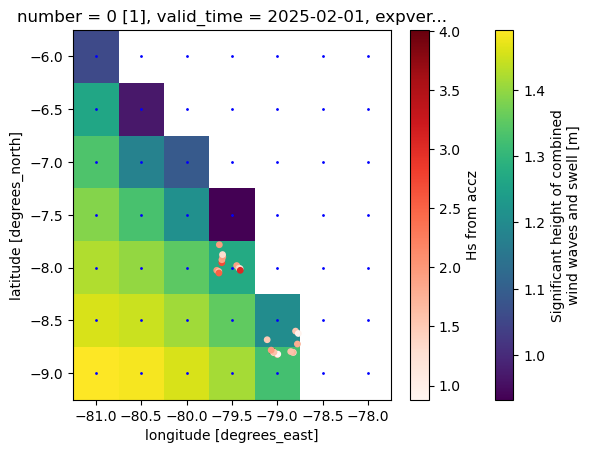

In [186]:
era5_wave.isel(valid_time=0).swh.plot()
plt.scatter(Hs_df['lon'], Hs_df['lat'],  s=15, c=Hs_df['Hs_band'],cmap='Reds')
plt.colorbar(label='Hs from accz')

lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

# load reanalysis data